In [89]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import *
import time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 110
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.3
COL = {"blue":"#3b6ea5","red":"#c0392b","green":"#5a9367","purple":"#8e44ad",
       "teal":"#5bb8b4","pink":"#e8a0bf","orange":"#e67e22","grey":"#7f8c8d"}
os.makedirs("figures", exist_ok=True)
os.makedirs("app_data", exist_ok=True)
os.makedirs("models", exist_ok=True)
def savefig(name):
    plt.tight_layout(); plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight"); plt.show()
print("Libraries loaded, folders ready (figures/, app_data/, models/).")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Libraries loaded, folders ready (figures/, app_data/, models/).


In [ ]:
spark session

In [90]:
spark = (
    SparkSession.builder
    .appName("BusDelayRiskScoring")
    .master("local[4]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
print("Spark version:", spark.version)
print("Cores:", spark.sparkContext.defaultParallelism)

26/07/19 00:25:41 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.1.1
Cores: 4


In [ ]:
 Duration parser helper

In [ ]:
def parse_duration(s):
    if not s or not s.startswith('PT'):
        return 0.0
    s = s[2:]
    mins, num = 0.0, ''
    for ch in s:
        if ch.isdigit():
            num += ch
        else:
            if ch == 'H': mins += float(num) * 60
            elif ch == 'M': mins += float(num)
            elif ch == 'S': mins += float(num) / 60
            num = ''
    return mins
print("parse_duration ready.")

In [ ]:
 TransXChange XML parser

In [ ]:
import xml.etree.ElementTree as ET
import glob

NS = {'txc': 'http://www.transxchange.org.uk/'}
WEEKDAYS = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

def parse_transxchange_file(path):
    rows = []
    try:
        tree = ET.parse(path)
    except ET.ParseError:
        return rows, 'parse_error'
    root = tree.getroot()
    routes = {}
    for r in root.findall('.//txc:Routes/txc:Route', NS):
        rid = r.attrib.get('id')
        desc = r.find('txc:Description', NS)
        routes[rid] = desc.text.strip() if desc is not None and desc.text else 'Unknown'
    journey_patterns = {}
    for svc in root.findall('.//txc:Services/txc:Service', NS):
        sc_el = svc.find('txc:ServiceCode', NS)
        service_code = sc_el.text if sc_el is not None else None
        line_el = svc.find('.//txc:Lines/txc:Line/txc:LineName', NS)
        line_name = line_el.text if line_el is not None else None
        std = svc.find('txc:StandardService', NS)
        if std is not None:
            for jp in std.findall('txc:JourneyPattern', NS):
                jp_id = jp.attrib.get('id')
                d_el = jp.find('txc:Direction', NS)
                rr_el = jp.find('txc:RouteRef', NS)
                journey_patterns[jp_id] = {
                    'direction': d_el.text if d_el is not None else None,
                    'route_ref': rr_el.text if rr_el is not None else None,
                    'service_code': service_code,
                    'line_name': line_name,
                }
    fname = os.path.basename(path)
    for vj in root.findall('.//txc:VehicleJourneys/txc:VehicleJourney', NS):
        vjc_el = vj.find('txc:VehicleJourneyCode', NS)
        dep_el = vj.find('txc:DepartureTime', NS)
        jpr_el = vj.find('txc:JourneyPatternRef', NS)
        lineref_el = vj.find('txc:LineRef', NS)
        jp_id = jpr_el.text if jpr_el is not None else None
        jp_info = journey_patterns.get(jp_id, {})
        route_desc = routes.get(jp_info.get('route_ref'), 'Unknown')
        op = vj.find('txc:OperatingProfile', NS)
        days = []
        if op is not None:
            dow = op.find('.//txc:RegularDayType/txc:DaysOfWeek', NS)
            if dow is not None:
                for child in dow:
                    tag = child.tag.split('}')[-1]
                    if tag in WEEKDAYS: days.append(tag)
                    elif tag == 'MondayToFriday': days.extend(WEEKDAYS[:5])
                    elif tag == 'MondayToSaturday': days.extend(WEEKDAYS[:6])
                    elif tag in ('MondayToSunday','Everyday'): days.extend(WEEKDAYS)
                    elif tag == 'Weekend': days.extend(['Saturday','Sunday'])
        total_runtime = 0.0
        for vjtl in vj.findall('txc:VehicleJourneyTimingLink', NS):
            rt_el = vjtl.find('txc:RunTime', NS)
            if rt_el is not None and rt_el.text:
                total_runtime += parse_duration(rt_el.text)
        rows.append({
            'source_file': fname,
            'service_code': jp_info.get('service_code'),
            'line_name': jp_info.get('line_name'),
            'vehicle_journey_code': vjc_el.text if vjc_el is not None else None,
            'line_ref': lineref_el.text if lineref_el is not None else None,
            'route_description': route_desc,
            'direction': jp_info.get('direction'),
            'scheduled_departure_time': dep_el.text if dep_el is not None else None,
            'operating_days': ','.join(sorted(set(days), key=WEEKDAYS.index)) if days else None,
            'scheduled_duration_minutes': round(total_runtime, 2),
        })
    return rows, None
print("Parser ready.")

In [ ]:
ingestion summary

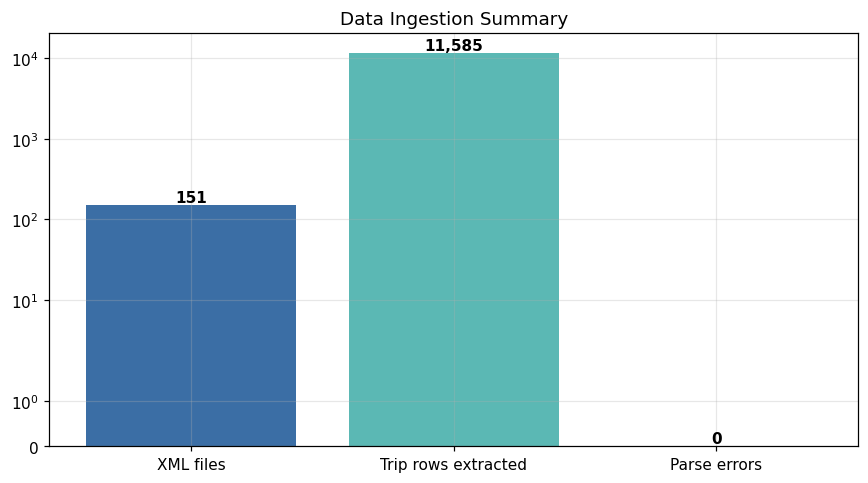

In [91]:
fig1, ax = plt.subplots(figsize=(8,4.5))
vals = [len(xml_files), len(all_rows), len(errors)]
labels = ["XML files", "Trip rows extracted", "Parse errors"]
bars = ax.bar(labels, vals, color=[COL["blue"], COL["teal"], COL["red"]])
for b,v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
ax.set_yscale("symlog")
ax.set_title("Data Ingestion Summary")
savefig("fig_ingestion_summary")

In [ ]:
trips per depot

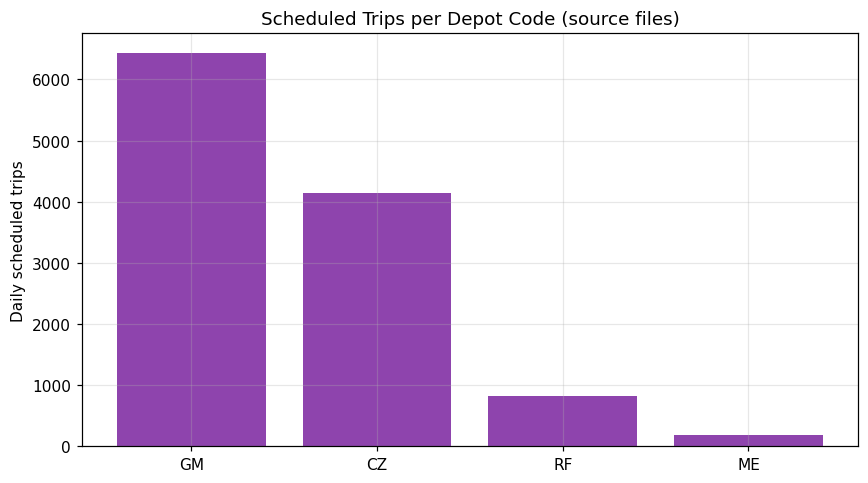

26/07/19 01:03:38 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 2042701 ms exceeds timeout 120000 ms
26/07/19 01:03:38 WARN SparkContext: Killing executors is not supported by current scheduler.


In [92]:
import re
depot = {}
for r in all_rows:
    m = re.search(r'SCMY-([A-Z]{2})', r['source_file'])
    key = m.group(1) if m else 'Other'
    depot[key] = depot.get(key, 0) + 1
dep_pd = pd.Series(depot).sort_values(ascending=False)
plt.figure(figsize=(8,4.5))
plt.bar(dep_pd.index, dep_pd.values, color=COL["purple"])
plt.title("Scheduled Trips per Depot Code (source files)")
plt.ylabel("Daily scheduled trips")
savefig("fig_trips_per_depot")

In [ ]:
 Schema + DataFrame

In [10]:
schema = StructType([
    StructField("source_file", StringType(), True),
    StructField("service_code", StringType(), True),
    StructField("line_name", StringType(), True),
    StructField("vehicle_journey_code", StringType(), True),
    StructField("line_ref", StringType(), True),
    StructField("route_description", StringType(), True),
    StructField("direction", StringType(), True),
    StructField("scheduled_departure_time", StringType(), True),
    StructField("operating_days", StringType(), True),
    StructField("scheduled_duration_minutes", DoubleType(), True),
])
trips_df = spark.createDataFrame(all_rows, schema=schema).repartition(4)
print("Rows:", trips_df.count(), "| Partitions:", trips_df.rdd.getNumPartitions())

[Stage 0:>                                                          (0 + 4) / 4]

Rows: 11585 | Partitions: 4


In [11]:
trips_df.printSchema()

root
 |-- source_file: string (nullable = true)
 |-- service_code: string (nullable = true)
 |-- line_name: string (nullable = true)
 |-- vehicle_journey_code: string (nullable = true)
 |-- line_ref: string (nullable = true)
 |-- route_description: string (nullable = true)
 |-- direction: string (nullable = true)
 |-- scheduled_departure_time: string (nullable = true)
 |-- operating_days: string (nullable = true)
 |-- scheduled_duration_minutes: double (nullable = true)



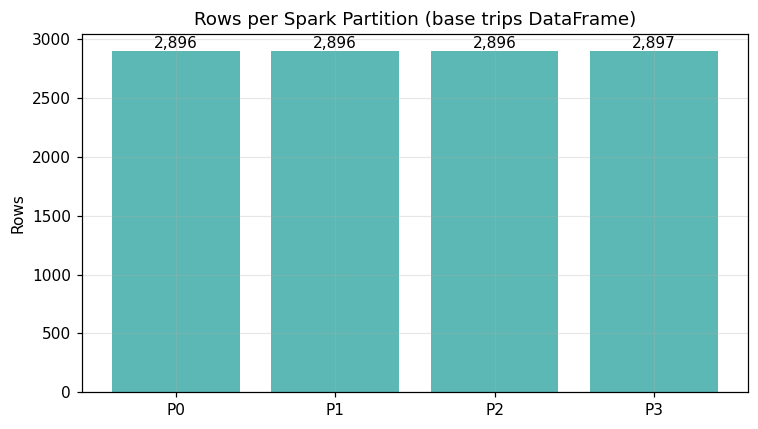

In [12]:
part_sizes = trips_df.rdd.glom().map(len).collect()
plt.figure(figsize=(7,4))
plt.bar([f"P{i}" for i in range(len(part_sizes))], part_sizes, color=COL["teal"])
for i,v in enumerate(part_sizes):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.title("Rows per Spark Partition (base trips DataFrame)")
plt.ylabel("Rows")
savefig("fig_partition_utilisation")

Generating a 1-year calendar DataFrame

In [13]:
from datetime import date, timedelta
START_DATE, END_DATE = date(2025, 8, 1), date(2026, 7, 31)
calendar_rows, d = [], START_DATE
while d <= END_DATE:
    calendar_rows.append((d.isoformat(), d.strftime('%A')))
    d += timedelta(days=1)
calendar_df = spark.createDataFrame(calendar_rows,
    schema=StructType([StructField("calendar_date", StringType(), True),
                       StructField("day_of_week", StringType(), True)]))
print("Calendar days:", calendar_df.count())

Calendar days: 365


 Exploding the operating days and joining to the calendar

In [14]:
trips_exploded = (trips_df.filter(F.col("operating_days").isNotNull())
    .withColumn("operating_day", F.explode(F.split(F.col("operating_days"), ","))))
trip_instances = (trips_exploded
    .join(calendar_df, trips_exploded.operating_day == calendar_df.day_of_week, "inner")
    .drop("day_of_week").repartition(8).cache())
n_daily = trips_df.count(); n_exploded = trips_exploded.count(); n_annual = trip_instances.count()
print(f"daily trips {n_daily:,} -> exploded {n_exploded:,} -> annual instances {n_annual:,}")

[Stage 32:====================================>                     (5 + 3) / 8]

daily trips 11,585 -> exploded 30,861 -> annual instances 1,609,696


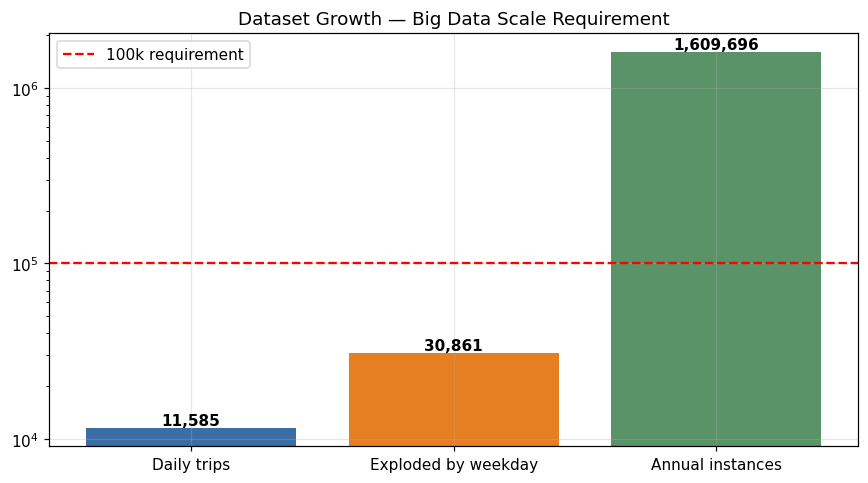

In [15]:
plt.figure(figsize=(8,4.5))
stages = ["Daily trips", "Exploded by weekday", "Annual instances"]
vals = [n_daily, n_exploded, n_annual]
bars = plt.bar(stages, vals, color=[COL["blue"], COL["orange"], COL["green"]])
for b,v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
plt.axhline(100000, color="red", linestyle="--", label="100k requirement")
plt.yscale("log"); plt.legend()
plt.title("Dataset Growth — Big Data Scale Requirement")
savefig("fig_scale_growth")

In [17]:
real_sample = pd.read_csv("data/location/all_siri_vm_analysed.csv")
print("Real AVL rows:", len(real_sample))
print(real_sample.columns.tolist())

Real AVL rows: 2260
['Version', 'ResponseTimestamp (ServiceDelivery)', 'ProducerRef', 'ResponseTimestamp (VehicleMonitoringDelivery)', 'RequestMessageRef', 'ValidUntil', 'ShortestPossibleCycle', 'RecordedAtTime', 'ItemIdentifier', 'ValidUntilTime', 'LineRef', 'DirectionRef', 'DataFrameRef', 'DatedVehicleJourneyRef', 'PublishedLineName', 'OperatorRef', 'OriginRef', 'OriginName', 'DestinationRef', 'DestinationName', 'OriginAimedDepartureTime', 'Longitude', 'Latitude', 'Bearing', 'VehicleRef', 'BlockRef', 'DriverRef']


real AVL sample vehicle positions

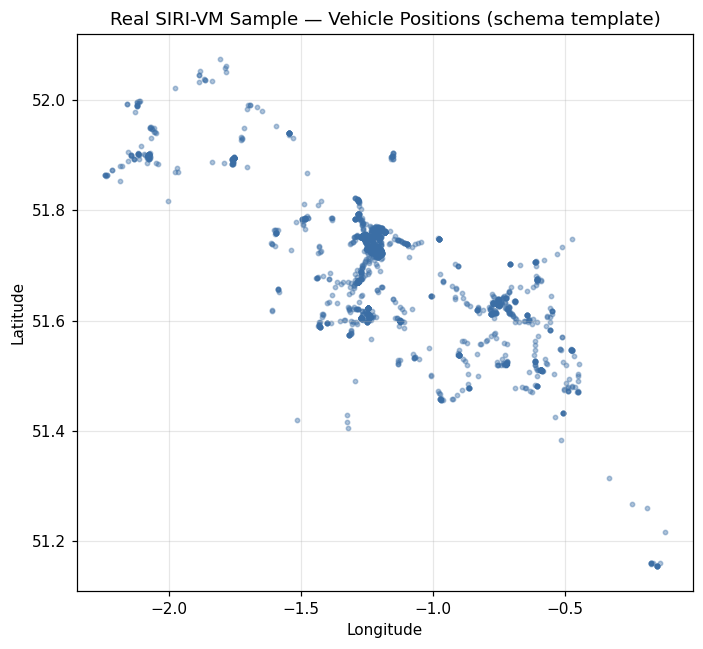

In [18]:
plt.figure(figsize=(6.5,6))
plt.scatter(real_sample["Longitude"], real_sample["Latitude"], s=8, alpha=0.4, color=COL["blue"])
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Real SIRI-VM Sample — Vehicle Positions (schema template)")
savefig("fig_real_avl_positions")

In [19]:
np.random.seed(42)
unique_routes = sorted(set(r["route_description"] for r in all_rows))
route_risk_seed = {r: np.random.uniform(0.6, 1.8) for r in unique_routes}
route_risk_bc = spark.sparkContext.broadcast(route_risk_seed)
print("Routes seeded:", len(route_risk_seed))

Routes seeded: 294


apply the synthetic delay + coordinate UDFs

In [20]:
from pyspark.sql.types import DoubleType

@F.udf(returnType=DoubleType())
def delay_udf(hour, route_desc, day_of_week):
    peak = 1.6 if hour in (7, 8, 9, 16, 17, 18) else 1.0
    weekend = 0.7 if day_of_week in ("Saturday", "Sunday") else 1.0
    route_factor = route_risk_bc.value.get(route_desc, 1.0)
    return round(float(np.random.gamma(2.0, 2.2 * peak * weekend * route_factor) - 2.0), 2)

@F.udf(returnType=DoubleType())
def lat_udf(): return float(np.random.uniform(53.30, 53.48))
@F.udf(returnType=DoubleType())
def lon_udf(): return float(np.random.uniform(-2.98, -2.65))

trip_instances = (trip_instances
    .withColumn("hour", F.hour(F.to_timestamp("scheduled_departure_time", "HH:mm:ss")))
    .withColumn("delay_minutes", delay_udf("hour", "route_description", "operating_day"))
    .withColumn("synthetic_latitude", lat_udf())
    .withColumn("synthetic_longitude", lon_udf())
    .cache())
trip_instances.select("route_description","calendar_date","hour","delay_minutes").show(5, truncate=False)

[Stage 42:=============================>                            (4 + 4) / 8]

+----------------------------------------------------+-------------+----+-------------+
|route_description                                   |calendar_date|hour|delay_minutes|
+----------------------------------------------------+-------------+----+-------------+
|Chester - Ellesmere Port - Runcorn                  |2025-08-28   |10  |-1.05        |
|Liverpool - Kirkby                                  |2025-09-04   |18  |5.82         |
|Vicar's Cross, Queens Road - Chester Bus Interchange|2025-10-03   |11  |0.55         |
|Liverpool ONE - South Parkway                       |2026-03-12   |23  |1.5          |
|Chester - Blacon Parade                             |2025-08-09   |17  |0.03         |
+----------------------------------------------------+-------------+----+-------------+
only showing top 5 rows


Data cleaning — nulls, duplicates, cache (with before/after counts)

In [21]:
rows_before = trip_instances.count()
nulls_before = trip_instances.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ["route_description","scheduled_departure_time","delay_minutes","operating_day","direction","line_name"]
]).toPandas().iloc[0]

trips_clean = (trip_instances
    .dropna(subset=["route_description","scheduled_departure_time","delay_minutes"])
    .dropDuplicates(["vehicle_journey_code","calendar_date"])
    .repartition(8).cache())
rows_after = trips_clean.count()
print(f"Rows before: {rows_before:,}  ->  after cleaning: {rows_after:,}")

26/07/18 18:32:19 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 71:=============================>                            (4 + 4) / 8]

Rows before: 1,609,696  ->  after cleaning: 896,000


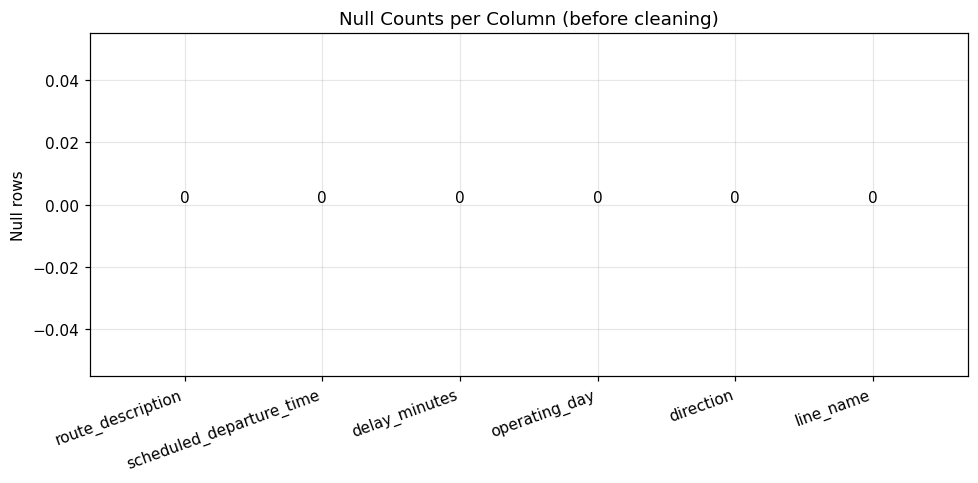

In [22]:
plt.figure(figsize=(9,4.5))
plt.bar(nulls_before.index, nulls_before.values, color=COL["red"])
for i,v in enumerate(nulls_before.values):
    plt.text(i, v, f"{int(v):,}", ha="center", va="bottom")
plt.title("Null Counts per Column (before cleaning)")
plt.xticks(rotation=20, ha="right"); plt.ylabel("Null rows")
savefig("fig_nulls_before")

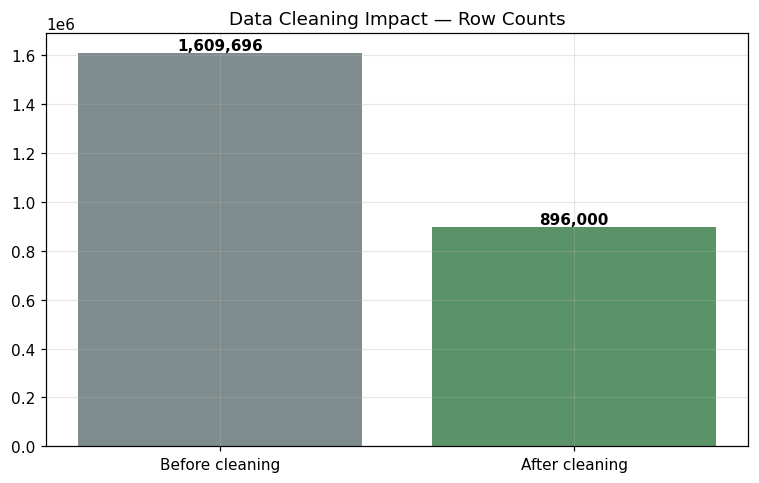

In [23]:
plt.figure(figsize=(7,4.5))
bars = plt.bar(["Before cleaning","After cleaning"], [rows_before, rows_after], color=[COL["grey"], COL["green"]])
for b,v in zip(bars,[rows_before, rows_after]):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
plt.title("Data Cleaning Impact — Row Counts")
savefig("fig_cleaning_impact")

Persist cleaned data to Parquet (checkpoint) and export app sample

In [24]:
trips_clean.write.mode("overwrite").parquet("checkpoint_trips_clean.parquet")
trips_clean.sample(fraction=0.01, seed=42).toPandas().to_csv("app_data/sample_trips.csv", index=False)
print("Parquet checkpoint + app sample written.")

Parquet checkpoint + app sample written.


In [25]:
from pyspark.sql.functions import skewness, kurtosis, stddev, mean, expr
stats_pd = trips_clean.select(
    mean("delay_minutes").alias("mean"),
    expr("percentile_approx(delay_minutes, 0.5)").alias("median"),
    stddev("delay_minutes").alias("std"),
    skewness("delay_minutes").alias("skewness"),
    kurtosis("delay_minutes").alias("kurtosis"),
).toPandas().iloc[0]
print(stats_pd)

mean        4.095666
median      2.680000
std         5.146305
skewness    2.066742
kurtosis    7.020869
Name: 0, dtype: float64


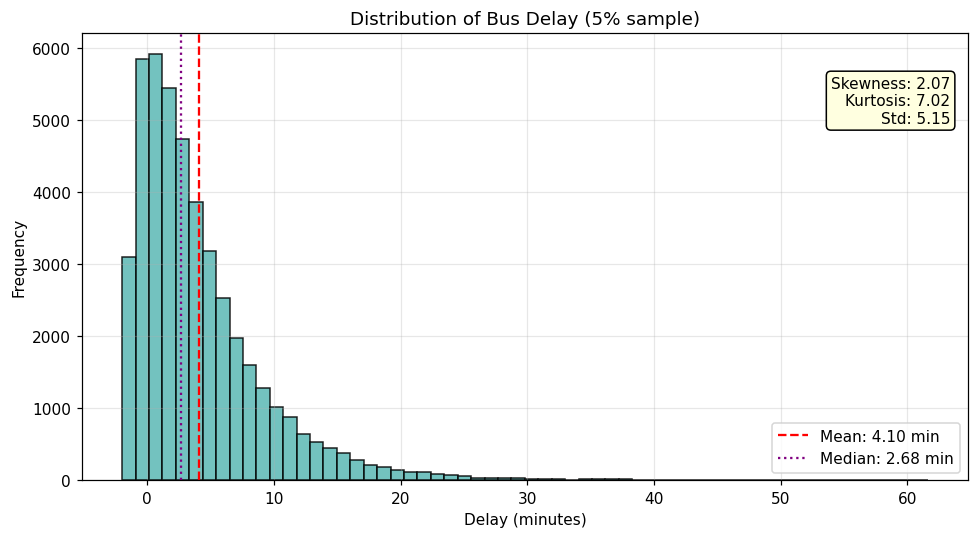

In [26]:
samp = trips_clean.select("delay_minutes").sample(fraction=0.05, seed=42).toPandas()
plt.figure(figsize=(9,5))
plt.hist(samp["delay_minutes"], bins=60, color=COL["teal"], edgecolor="black", alpha=0.85)
plt.axvline(stats_pd["mean"], color="red", linestyle="--", label=f"Mean: {stats_pd['mean']:.2f} min")
plt.axvline(stats_pd["median"], color="purple", linestyle=":", label=f"Median: {stats_pd['median']:.2f} min")
plt.legend()
plt.text(0.98, 0.80, f"Skewness: {stats_pd['skewness']:.2f}\nKurtosis: {stats_pd['kurtosis']:.2f}\nStd: {stats_pd['std']:.2f}",
         transform=plt.gca().transAxes, ha="right",
         bbox=dict(boxstyle="round", facecolor="lightyellow"))
plt.xlabel("Delay (minutes)"); plt.ylabel("Frequency")
plt.title("Distribution of Bus Delay (5% sample)")
savefig("fig_delay_distribution")

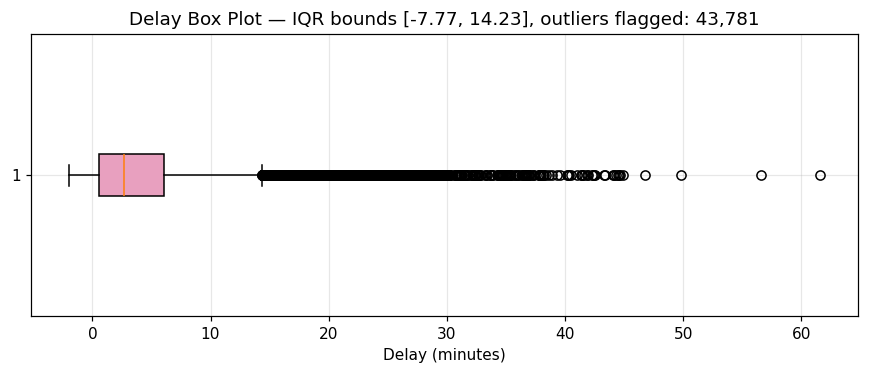

In [27]:
q1, q3 = trips_clean.approxQuantile("delay_minutes", [0.25, 0.75], 0.01)
iqr = q3 - q1; lo, hi = q1-1.5*iqr, q3+1.5*iqr
n_out = trips_clean.filter((F.col("delay_minutes")<lo)|(F.col("delay_minutes")>hi)).count()
plt.figure(figsize=(8,3.5))
plt.boxplot(samp["delay_minutes"], vert=False, patch_artist=True,
            boxprops=dict(facecolor=COL["pink"]))
plt.title(f"Delay Box Plot — IQR bounds [{lo:.2f}, {hi:.2f}], outliers flagged: {n_out:,}")
plt.xlabel("Delay (minutes)")
savefig("fig_delay_boxplot")

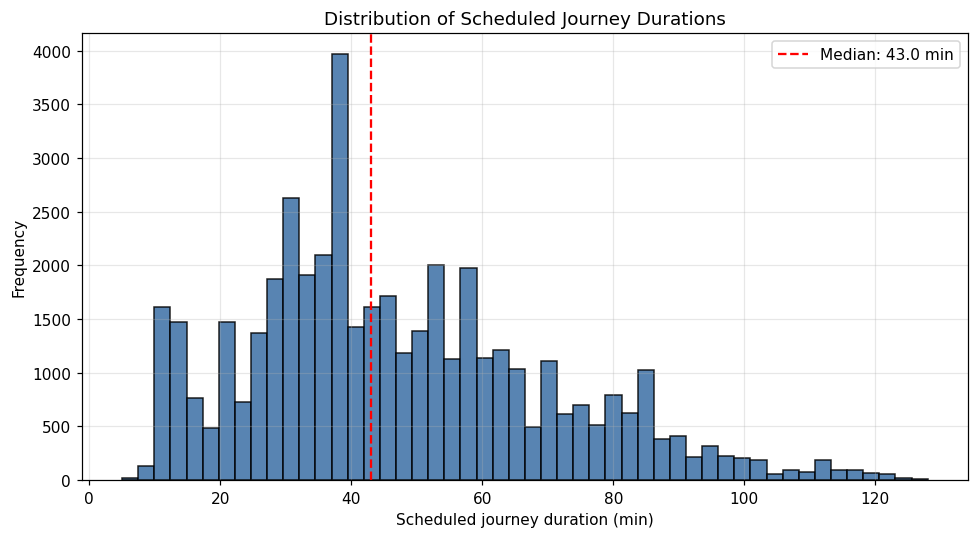

In [28]:
dur = trips_clean.select("scheduled_duration_minutes").sample(fraction=0.05, seed=42).toPandas()
med_dur = dur["scheduled_duration_minutes"].median()
plt.figure(figsize=(9,5))
plt.hist(dur["scheduled_duration_minutes"], bins=50, color=COL["blue"], edgecolor="black", alpha=0.85)
plt.axvline(med_dur, color="red", linestyle="--", label=f"Median: {med_dur:.1f} min")
plt.legend(); plt.xlabel("Scheduled journey duration (min)"); plt.ylabel("Frequency")
plt.title("Distribution of Scheduled Journey Durations")
savefig("fig_duration_distribution")

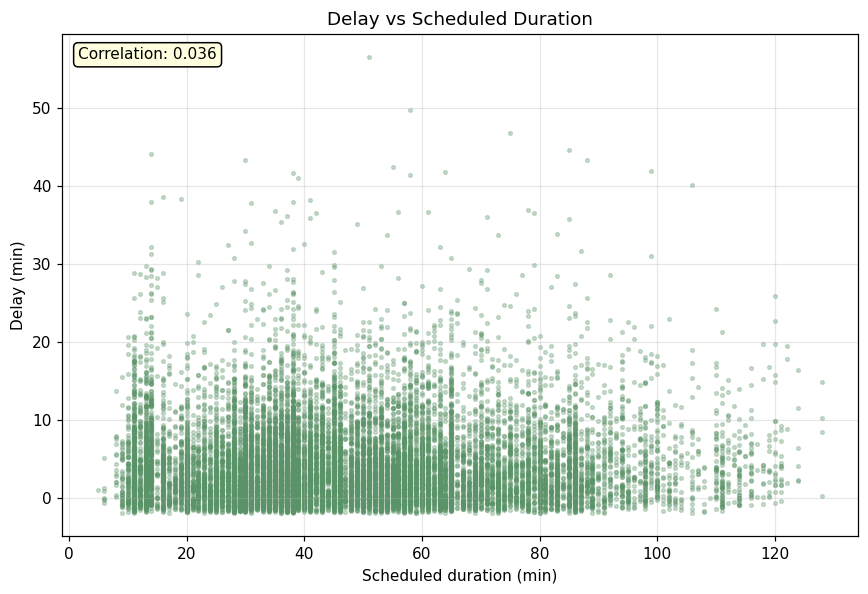

In [29]:
sc = trips_clean.select("scheduled_duration_minutes","delay_minutes").sample(fraction=0.02, seed=42).toPandas()
corr = sc.corr().iloc[0,1]
plt.figure(figsize=(8,5.5))
plt.scatter(sc["scheduled_duration_minutes"], sc["delay_minutes"], s=6, alpha=0.3, color=COL["green"])
plt.text(0.02, 0.95, f"Correlation: {corr:.3f}", transform=plt.gca().transAxes,
         bbox=dict(boxstyle="round", facecolor="lightyellow"))
plt.xlabel("Scheduled duration (min)"); plt.ylabel("Delay (min)")
plt.title("Delay vs Scheduled Duration")
savefig("fig_delay_vs_duration")

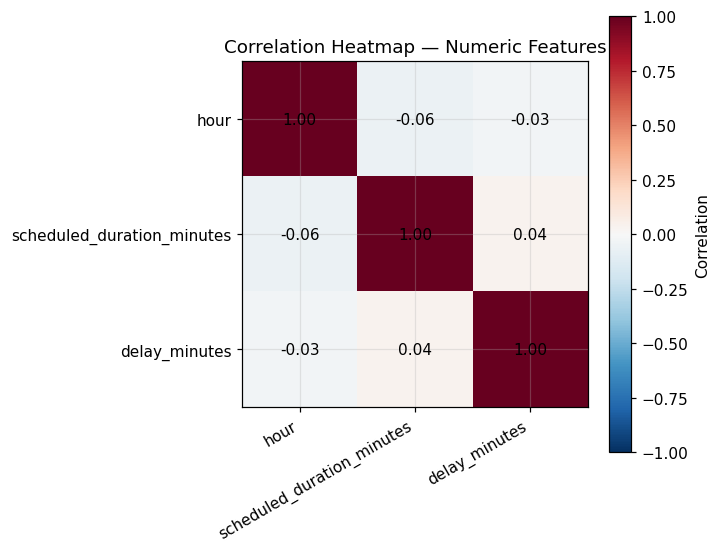

In [30]:
num = trips_clean.select("hour","scheduled_duration_minutes","delay_minutes").sample(fraction=0.02, seed=42).toPandas()
cm = num.corr()
plt.figure(figsize=(6.5,5.5))
im = plt.imshow(cm, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(cm)), cm.columns, rotation=30, ha="right")
plt.yticks(range(len(cm)), cm.columns)
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, f"{cm.iloc[i,j]:.2f}", ha="center", va="center")
plt.title("Correlation Heatmap — Numeric Features")
savefig("fig_corr_heatmap")

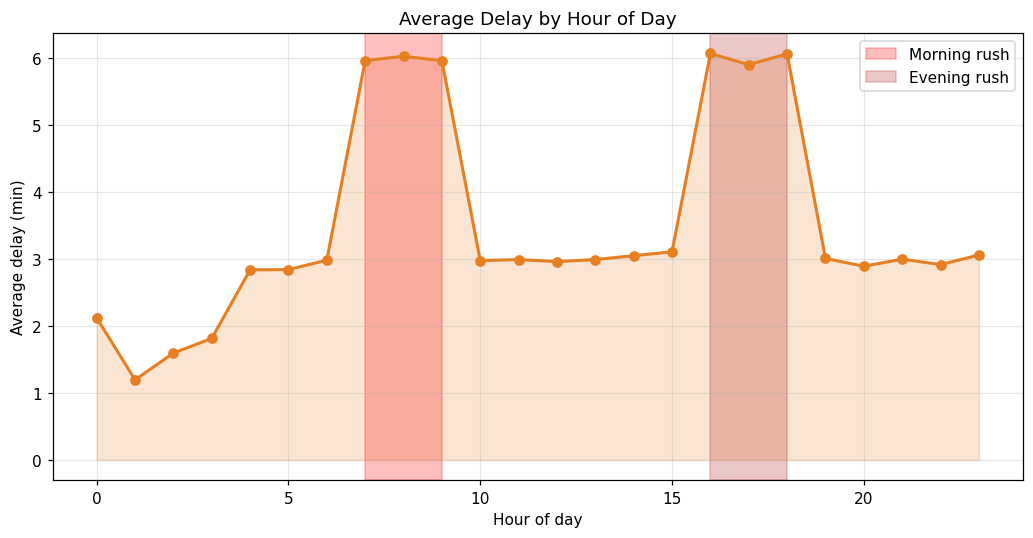

In [31]:
dbh = (trips_clean.groupBy("hour").agg(F.mean("delay_minutes").alias("avg_delay"))
       .orderBy("hour").toPandas())
dbh.to_csv("app_data/delay_by_hour.csv", index=False)
plt.figure(figsize=(9.5,5))
plt.plot(dbh["hour"], dbh["avg_delay"], marker="o", color=COL["orange"], linewidth=2)
plt.fill_between(dbh["hour"], dbh["avg_delay"], alpha=0.2, color=COL["orange"])
plt.axvspan(7, 9, alpha=0.25, color="red", label="Morning rush")
plt.axvspan(16, 18, alpha=0.25, color="firebrick", label="Evening rush")
plt.legend(); plt.xlabel("Hour of day"); plt.ylabel("Average delay (min)")
plt.title("Average Delay by Hour of Day")
savefig("fig_delay_by_hour")

Chart — rush hour vs non-rush comparison

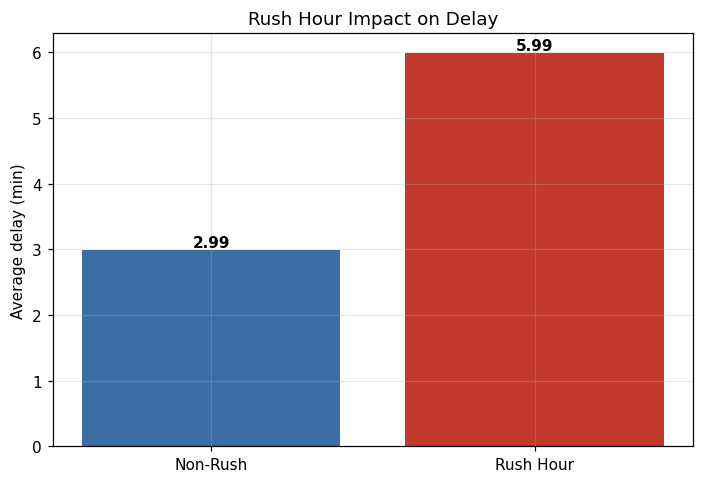

In [32]:
rush = (trips_clean.withColumn("is_rush", F.when(F.col("hour").isin(7,8,9,16,17,18), "Rush Hour").otherwise("Non-Rush"))
        .groupBy("is_rush").agg(F.mean("delay_minutes").alias("avg_delay")).toPandas())
plt.figure(figsize=(6.5,4.5))
bars = plt.bar(rush["is_rush"], rush["avg_delay"], color=[COL["blue"], COL["red"]])
for b,v in zip(bars, rush["avg_delay"]):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontweight="bold")
plt.ylabel("Average delay (min)"); plt.title("Rush Hour Impact on Delay")
savefig("fig_rush_impact")

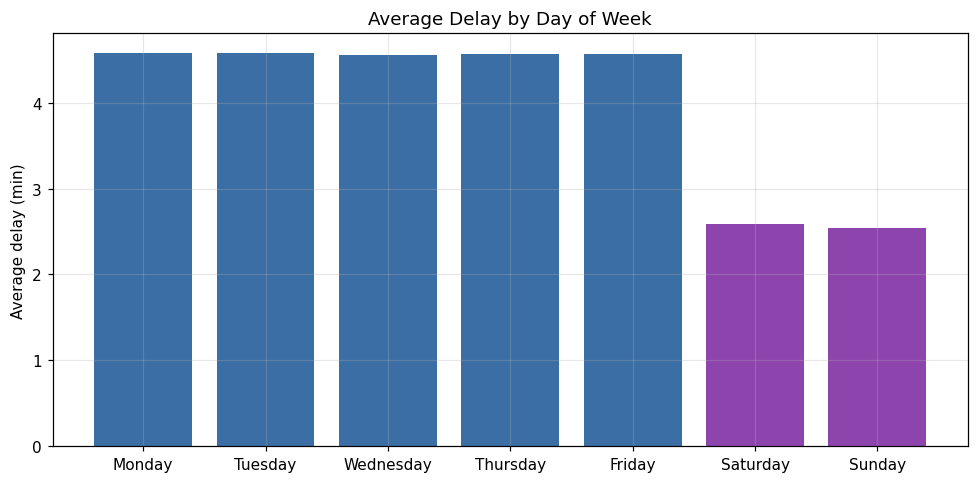

In [33]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = (trips_clean.groupBy("operating_day").agg(F.mean("delay_minutes").alias("avg_delay")).toPandas())
dow["operating_day"] = pd.Categorical(dow["operating_day"], categories=order, ordered=True)
dow = dow.sort_values("operating_day")
dow.to_csv("app_data/delay_by_dow.csv", index=False)
plt.figure(figsize=(9,4.5))
colors = [COL["blue"]]*5 + [COL["purple"]]*2
plt.bar(dow["operating_day"], dow["avg_delay"], color=colors)
plt.ylabel("Average delay (min)"); plt.title("Average Delay by Day of Week")
savefig("fig_delay_by_dow")

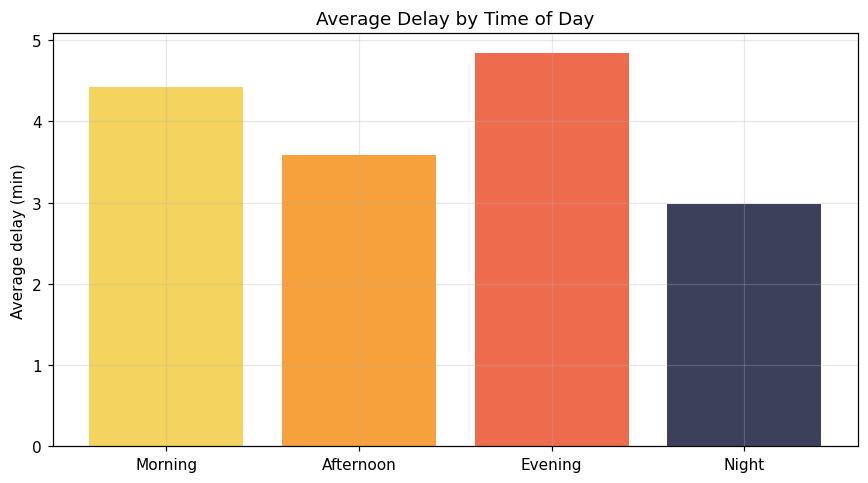

In [34]:
period = (trips_clean.withColumn("period",
    F.when(F.col("hour") < 12, "Morning")
     .when(F.col("hour") < 17, "Afternoon")
     .when(F.col("hour") < 21, "Evening").otherwise("Night"))
    .groupBy("period").agg(F.mean("delay_minutes").alias("avg_delay")).toPandas())
p_order = ["Morning","Afternoon","Evening","Night"]
period["period"] = pd.Categorical(period["period"], categories=p_order, ordered=True)
period = period.sort_values("period")
plt.figure(figsize=(8,4.5))
plt.bar(period["period"], period["avg_delay"], color=["#f4d35e","#f6a13c","#ee6c4d","#3d405b"])
plt.ylabel("Average delay (min)"); plt.title("Average Delay by Time of Day")
savefig("fig_delay_by_period")

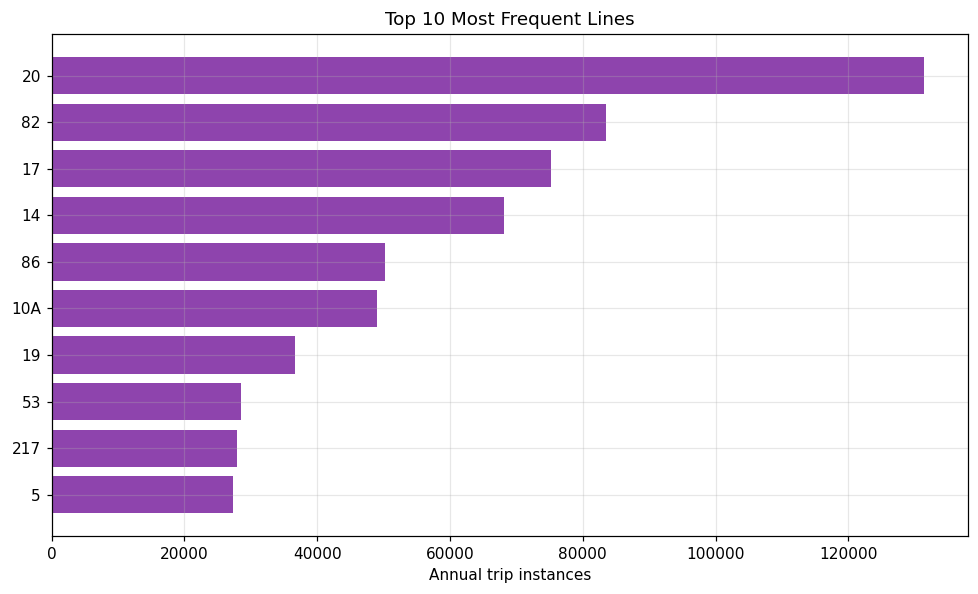

In [35]:
freq = (trips_clean.groupBy("line_name").agg(F.count("*").alias("trips"))
        .orderBy(F.desc("trips")).limit(10).toPandas())
freq.to_csv("app_data/top_routes_freq.csv", index=False)
plt.figure(figsize=(9,5.5))
plt.barh(freq["line_name"][::-1].astype(str), freq["trips"][::-1], color=COL["purple"])
plt.xlabel("Annual trip instances"); plt.title("Top 10 Most Frequent Lines")
savefig("fig_top_frequent")

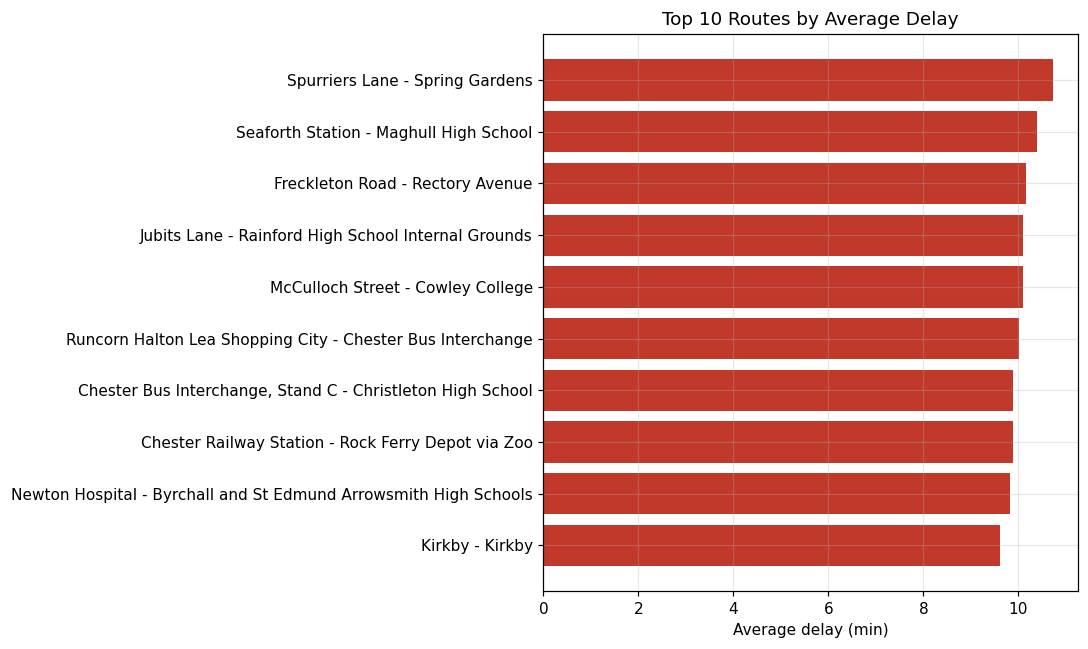

In [36]:
worst = (trips_clean.groupBy("route_description")
         .agg(F.mean("delay_minutes").alias("avg_delay"), F.count("*").alias("n"))
         .filter(F.col("n") > 100).orderBy(F.desc("avg_delay")).limit(10).toPandas())
worst.to_csv("app_data/worst_routes.csv", index=False)
plt.figure(figsize=(10,6))
plt.barh(worst["route_description"][::-1], worst["avg_delay"][::-1], color=COL["red"])
plt.xlabel("Average delay (min)"); plt.title("Top 10 Routes by Average Delay")
savefig("fig_worst_routes")

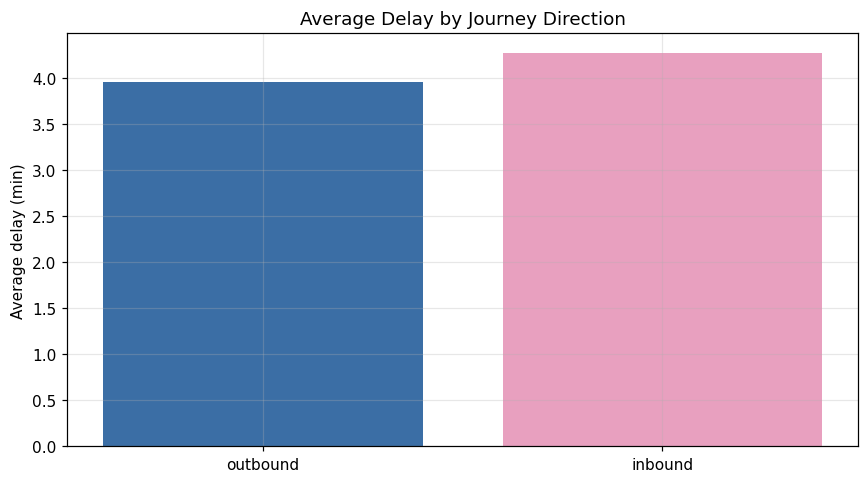

In [37]:
dirn = (trips_clean.filter(F.col("direction").isNotNull())
        .groupBy("direction").agg(F.mean("delay_minutes").alias("avg_delay")).toPandas())
plt.figure(figsize=(8,4.5))
plt.bar(dirn["direction"], dirn["avg_delay"],
        color=[COL["blue"], COL["pink"], COL["teal"], COL["orange"]][:len(dirn)])
plt.ylabel("Average delay (min)"); plt.title("Average Delay by Journey Direction")
savefig("fig_delay_by_direction")

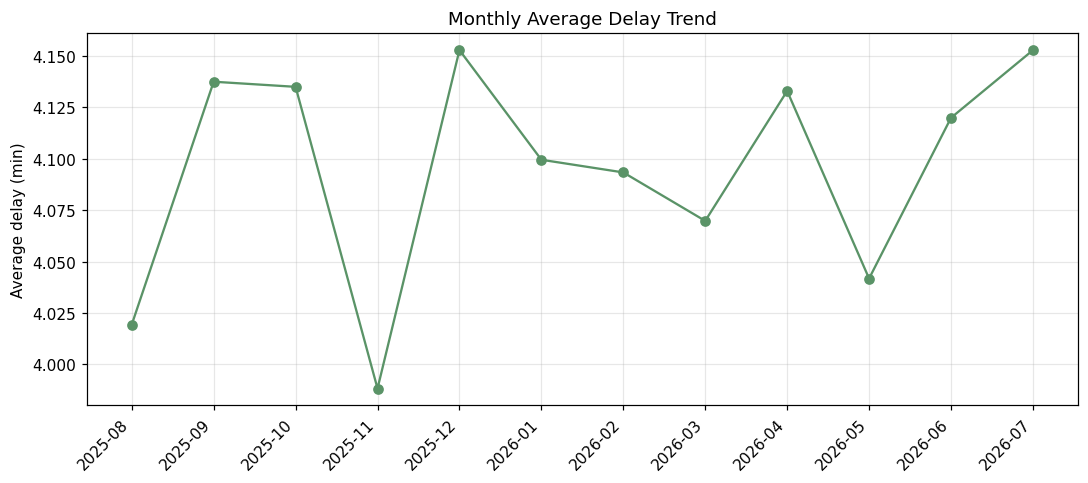

In [38]:
mon = (trips_clean.withColumn("month", F.substring("calendar_date", 1, 7))
       .groupBy("month").agg(F.mean("delay_minutes").alias("avg_delay"))
       .orderBy("month").toPandas())
plt.figure(figsize=(10,4.5))
plt.plot(mon["month"], mon["avg_delay"], marker="o", color=COL["green"])
plt.xticks(rotation=45, ha="right"); plt.ylabel("Average delay (min)")
plt.title("Monthly Average Delay Trend")
savefig("fig_monthly_trend")

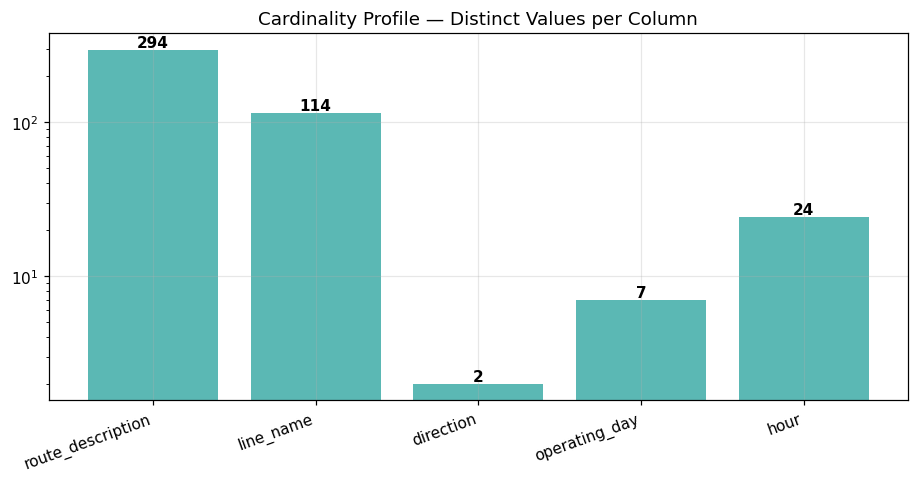

In [39]:
card = {c: trips_clean.select(c).distinct().count()
        for c in ["route_description","line_name","direction","operating_day","hour"]}
plt.figure(figsize=(8.5,4.5))
plt.bar(card.keys(), card.values(), color=COL["teal"])
for i,(k,v) in enumerate(card.items()):
    plt.text(i, v, str(v), ha="center", va="bottom", fontweight="bold")
plt.yscale("log"); plt.xticks(rotation=20, ha="right")
plt.title("Cardinality Profile — Distinct Values per Column")
savefig("fig_cardinality")

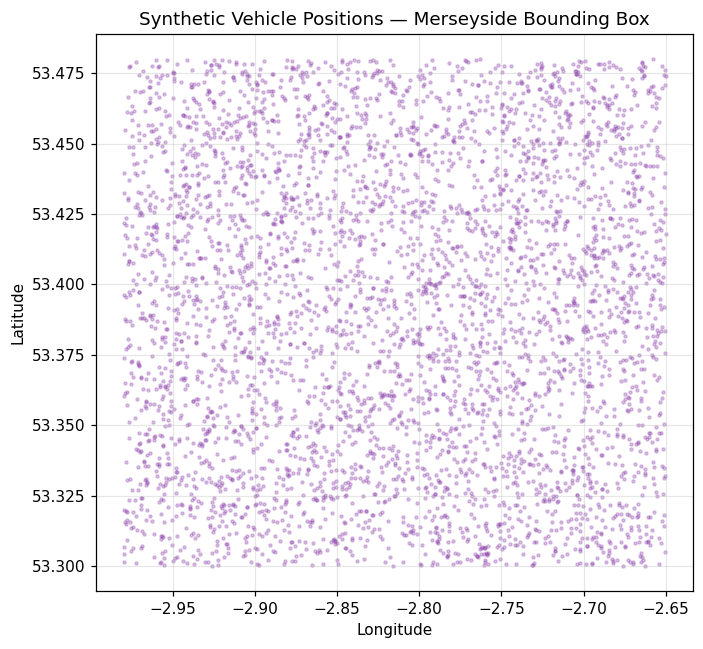

In [40]:
pos = trips_clean.select("synthetic_longitude","synthetic_latitude").sample(fraction=0.005, seed=42).toPandas()
plt.figure(figsize=(6.5,6))
plt.scatter(pos["synthetic_longitude"], pos["synthetic_latitude"], s=4, alpha=0.3, color=COL["purple"])
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Synthetic Vehicle Positions — Merseyside Bounding Box")
savefig("fig_synthetic_positions")

In [41]:
trips_clean.createOrReplaceTempView("trips")
sql_result = spark.sql("""
    SELECT route_description, COUNT(*) AS trip_count,
           ROUND(AVG(delay_minutes),2) AS avg_delay,
           ROUND(STDDEV(delay_minutes),2) AS std_delay
    FROM trips GROUP BY route_description
    HAVING COUNT(*) > 100 ORDER BY avg_delay DESC LIMIT 10
""").toPandas()
print(sql_result.to_string(index=False))

                                               route_description  trip_count  avg_delay  std_delay
                                 Spurriers Lane - Spring Gardens         261      10.72       8.53
                          Seaforth Station - Maghull High School         261      10.39       9.16
                                Freckleton Road - Rectory Avenue         261      10.15       7.97
             Jubits Lane - Rainford High School Internal Grounds         261      10.10       8.37
                               McCulloch Street - Cowley College         261      10.09       8.31
      Runcorn Halton Lea Shopping City - Chester Bus Interchange         304      10.01       8.43
      Chester Bus Interchange, Stand C - Christleton High School         261       9.89       8.62
              Chester Railway Station - Rock Ferry Depot via Zoo         126       9.88       8.21
Newton Hospital - Byrchall and St Edmund Arrowsmith High Schools         261       9.82       8.50
          

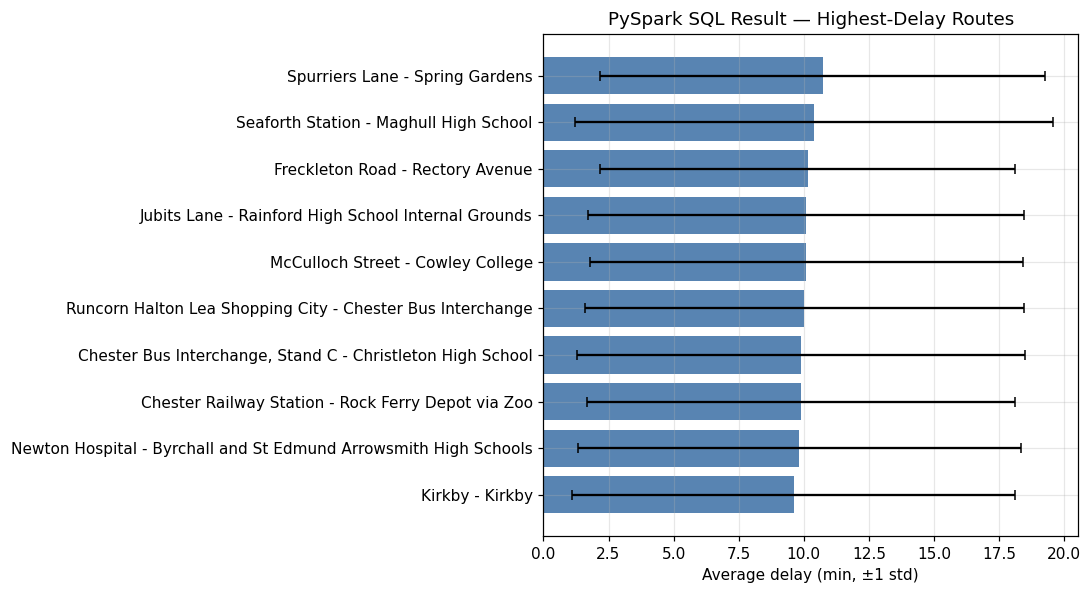

In [42]:
plt.figure(figsize=(10,5.5))
plt.barh(sql_result["route_description"][::-1], sql_result["avg_delay"][::-1],
         xerr=sql_result["std_delay"][::-1], color=COL["blue"], alpha=0.85, capsize=3)
plt.xlabel("Average delay (min, ±1 std)"); plt.title("PySpark SQL Result — Highest-Delay Routes")
savefig("fig_sql_result")

 Lazy evaluation & DAG — explain plan, then trigger the action

In [43]:
lazy_plan = trips_clean.filter(F.col("delay_minutes") > 5).groupBy("line_name").count()
print("Plan built lazily — DAG below:")
lazy_plan.explain()
print("Action result (rows delayed >5min):", lazy_plan.count())

Plan built lazily — DAG below:
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[line_name#2], functions=[count(1)])
   +- Exchange hashpartitioning(line_name#2, 8), ENSURE_REQUIREMENTS, [plan_id=2422]
      +- HashAggregate(keys=[line_name#2], functions=[partial_count(1)])
         +- Project [line_name#2]
            +- Filter (isnotnull(delay_minutes#441) AND (delay_minutes#441 > 5.0))
               +- InMemoryTableScan [delay_minutes#441, line_name#2], [isnotnull(delay_minutes#441), (delay_minutes#441 > 5.0)]
                     +- InMemoryRelation [source_file#0, service_code#1, line_name#2, vehicle_journey_code#3, line_ref#4, route_description#5, direction#6, scheduled_departure_time#7, operating_days#8, scheduled_duration_minutes#9, operating_day#33, calendar_date#24, hour#439, delay_minutes#441, synthetic_latitude#443, synthetic_longitude#445], StorageLevel(disk, memory, deserialized, 1 replicas)
                           +- AdaptiveSparkPlan isF

 Feature engineering — historical average delay (leakage-safe) + indexers + assembler

In [44]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

w = (Window.partitionBy("route_description").orderBy("calendar_date")
     .rowsBetween(Window.unboundedPreceding, -1))
trips_features = trips_clean.withColumn("historical_avg_delay", F.avg("delay_minutes").over(w))
global_mean = trips_clean.agg(F.mean("delay_minutes")).first()[0]
trips_features = trips_features.fillna({"historical_avg_delay": global_mean})

route_indexer = StringIndexer(inputCol="route_description", outputCol="route_idx", handleInvalid="keep")
day_indexer   = StringIndexer(inputCol="operating_day", outputCol="day_idx", handleInvalid="keep")
FEATURES = ["hour","route_idx","day_idx","scheduled_duration_minutes","historical_avg_delay"]
assembler = VectorAssembler(inputCols=FEATURES, outputCol="features")

feature_pipeline = Pipeline(stages=[route_indexer, day_indexer, assembler])
feature_model = feature_pipeline.fit(trips_features)
trips_ml_ready = feature_model.transform(trips_features)
feature_model.write().overwrite().save("models/feature_pipeline")
print("Stages:", [type(s).__name__ for s in feature_pipeline.getStages()])
trips_ml_ready.select("features","delay_minutes").show(3, truncate=False)

Stages: ['StringIndexer', 'StringIndexer', 'VectorAssembler']
+--------------------------------------+-------------+
|features                              |delay_minutes|
+--------------------------------------+-------------+
|[13.0,93.0,0.0,20.0,4.095666439732159]|0.26         |
|[13.0,93.0,0.0,20.0,0.26]             |5.0          |
|[6.0,93.0,0.0,18.0,2.63]              |4.73         |
+--------------------------------------+-------------+
only showing top 3 rows


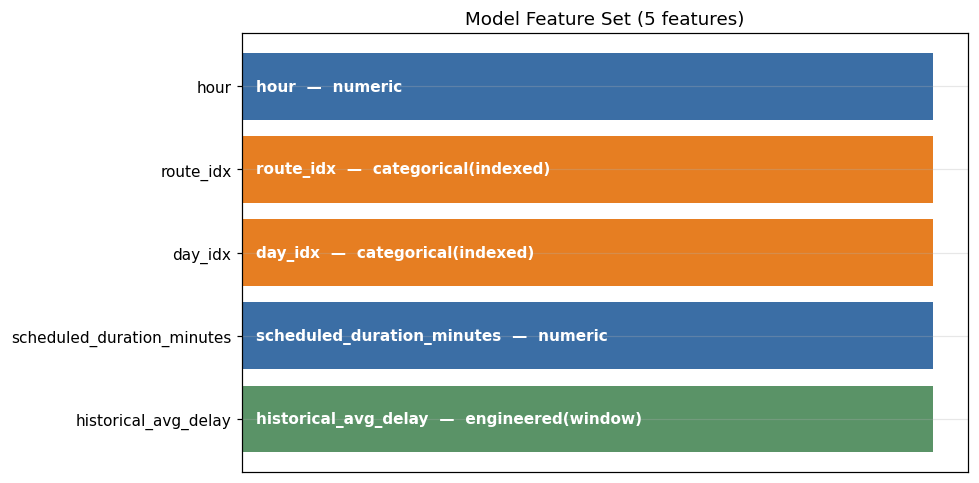

In [45]:
feat_desc = {"hour":"numeric","route_idx":"categorical(indexed)","day_idx":"categorical(indexed)",
             "scheduled_duration_minutes":"numeric","historical_avg_delay":"engineered(window)"}
plt.figure(figsize=(9,4.5))
colors = [COL["blue"] if "numeric" in v else COL["orange"] if "categorical" in v else COL["green"]
          for v in feat_desc.values()]
plt.barh(list(feat_desc.keys())[::-1], [1]*5, color=colors[::-1])
for i,(k,v) in enumerate(reversed(list(feat_desc.items()))):
    plt.text(0.02, i, f"{k}  —  {v}", va="center", fontweight="bold", color="white")
plt.xticks([]); plt.title("Model Feature Set (5 features)")
savefig("fig_feature_set")

In [46]:
SPLIT_DATE = "2026-06-01"
train_df = trips_ml_ready.filter(F.col("calendar_date") < SPLIT_DATE).cache()
n_train = train_df.count()
print(f"TRAIN rows (before {SPLIT_DATE}): {n_train:,}")

[Stage 458:==========================================>              (6 + 2) / 8]

TRAIN rows (before 2026-06-01): 745,430


In [47]:
test_df = trips_ml_ready.filter(F.col("calendar_date") >= SPLIT_DATE).cache()
n_test = test_df.count()
print(f"TEST rows (from {SPLIT_DATE}): {n_test:,}")

[Stage 482:============================>                            (4 + 4) / 8]

TEST rows (from 2026-06-01): 150,570


train/test split proportions

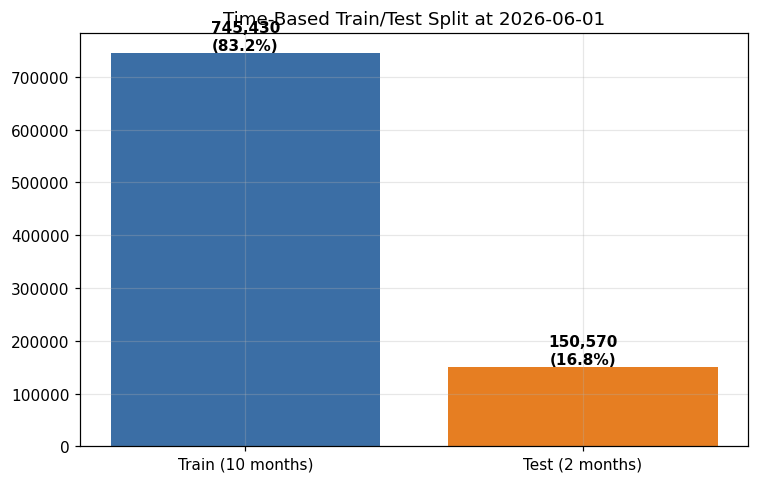

In [48]:
plt.figure(figsize=(7,4.5))
bars = plt.bar(["Train (10 months)","Test (2 months)"], [n_train, n_test], color=[COL["blue"], COL["orange"]])
for b,v in zip(bars,[n_train,n_test]):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:,}\n({100*v/(n_train+n_test):.1f}%)",
             ha="center", va="bottom", fontweight="bold")
plt.title(f"Time-Based Train/Test Split at {SPLIT_DATE}")
savefig("fig_split_bar")

split timeline (rows per month, coloured train vs test)

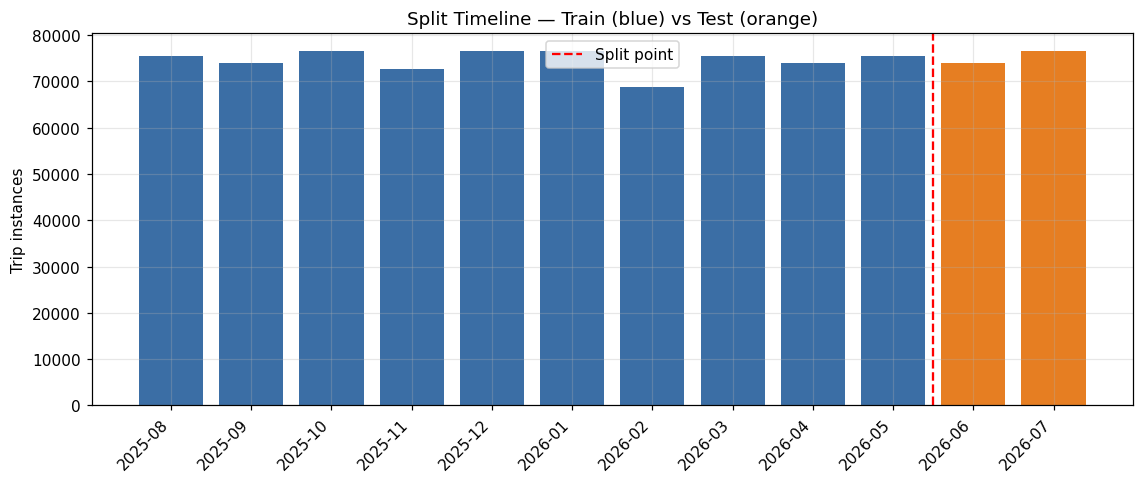

In [49]:
tl = (trips_ml_ready.withColumn("month", F.substring("calendar_date",1,7))
      .groupBy("month").count().orderBy("month").toPandas())
colors = [COL["blue"] if m < "2026-06" else COL["orange"] for m in tl["month"]]
plt.figure(figsize=(10.5,4.5))
plt.bar(tl["month"], tl["count"], color=colors)
plt.axvline(x=list(tl["month"]).index("2026-06")-0.5, color="red", linestyle="--", label="Split point")
plt.xticks(rotation=45, ha="right"); plt.ylabel("Trip instances"); plt.legend()
plt.title("Split Timeline — Train (blue) vs Test (orange)")
savefig("fig_split_timeline")

Train & evaluate 3 regression models (RMSE / MAE / R² / time)

In [50]:
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

ev_rmse = RegressionEvaluator(labelCol="delay_minutes", predictionCol="prediction", metricName="rmse")
ev_mae  = RegressionEvaluator(labelCol="delay_minutes", predictionCol="prediction", metricName="mae")
ev_r2   = RegressionEvaluator(labelCol="delay_minutes", predictionCol="prediction", metricName="r2")

models = {
    "LinearRegression": LinearRegression(featuresCol="features", labelCol="delay_minutes"),
    "RandomForest": RandomForestRegressor(featuresCol="features", labelCol="delay_minutes",
                                          numTrees=50, maxDepth=8, maxBins=320, seed=42),
    "GBTRegressor": GBTRegressor(featuresCol="features", labelCol="delay_minutes",
                                 maxIter=50, maxDepth=6, maxBins=320, seed=42),
}
results, fitted_models = [], {}
for name, m in models.items():
    t0 = time.time(); fitted = m.fit(train_df); tt = time.time() - t0
    preds = fitted.transform(test_df)
    rmse, mae, r2 = ev_rmse.evaluate(preds), ev_mae.evaluate(preds), ev_r2.evaluate(preds)
    fitted_models[name] = fitted
    results.append({"model": name, "rmse": round(rmse,3), "mae": round(mae,3), "r2": round(r2,3),
                    "train_time_sec": round(tt,2), "r2_per_second": round(r2/tt,4) if tt>0 else None})
    print(f"{name:18s} RMSE={rmse:.3f} MAE={mae:.3f} R2={r2:.3f} time={tt:.2f}s")
comparison_df = pd.DataFrame(results).sort_values("rmse")
comparison_df.to_csv("app_data/model_comparison.csv", index=False)
best_model_name = comparison_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_model.write().overwrite().save("models/best_regressor")
print("Best model:", best_model_name, "(saved to models/best_regressor)")

26/07/18 19:07:03 WARN Instrumentation: [b45352e7] regParam is zero, which might cause numerical instability and overfitting.
26/07/18 19:07:03 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/07/18 19:07:03 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
                                                                                

LinearRegression   RMSE=4.881 MAE=3.497 R2=0.109 time=1.73s


26/07/18 19:07:14 WARN DAGScheduler: Broadcasting large task binary with size 1072.1 KiB
26/07/18 19:07:18 WARN DAGScheduler: Broadcasting large task binary with size 1761.5 KiB
26/07/18 19:07:22 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
                                                                                

RandomForest       RMSE=4.648 MAE=3.329 R2=0.192 time=23.07s


26/07/18 19:08:09 WARN DAGScheduler: Broadcasting large task binary with size 1004.8 KiB
26/07/18 19:08:09 WARN DAGScheduler: Broadcasting large task binary with size 1009.6 KiB
26/07/18 19:08:10 WARN DAGScheduler: Broadcasting large task binary with size 1013.0 KiB
26/07/18 19:08:10 WARN DAGScheduler: Broadcasting large task binary with size 1014.0 KiB
26/07/18 19:08:10 WARN DAGScheduler: Broadcasting large task binary with size 1017.2 KiB
26/07/18 19:08:11 WARN DAGScheduler: Broadcasting large task binary with size 1023.3 KiB
26/07/18 19:08:11 WARN DAGScheduler: Broadcasting large task binary with size 1031.0 KiB
26/07/18 19:08:12 WARN DAGScheduler: Broadcasting large task binary with size 1037.3 KiB
26/07/18 19:08:12 WARN DAGScheduler: Broadcasting large task binary with size 1037.8 KiB
26/07/18 19:08:12 WARN DAGScheduler: Broadcasting large task binary with size 1041.7 KiB
26/07/18 19:08:12 WARN DAGScheduler: Broadcasting large task binary with size 1045.7 KiB
26/07/18 19:08:12 WAR

GBTRegressor       RMSE=4.633 MAE=3.318 R2=0.197 time=68.13s
Best model: GBTRegressor (saved to models/best_regressor)


R² comparison

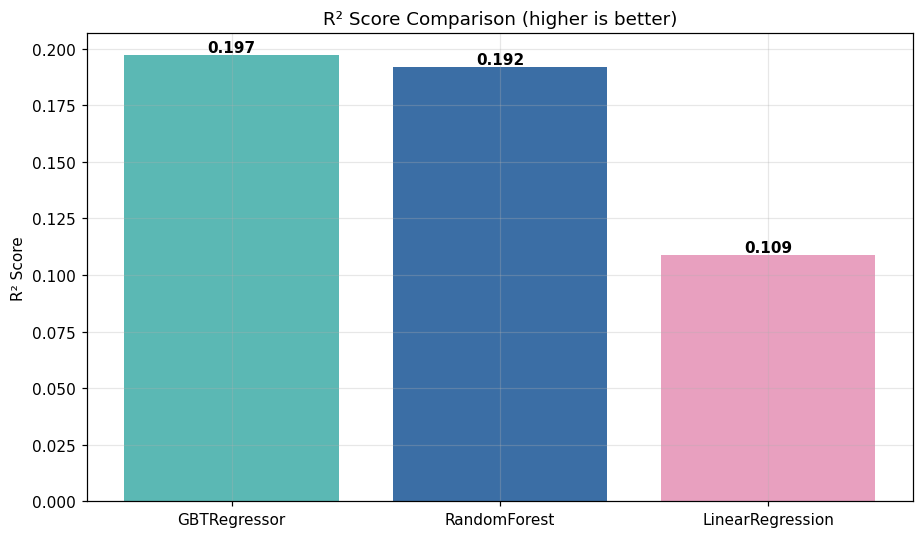

In [51]:
plt.figure(figsize=(8.5,5))
bars = plt.bar(comparison_df["model"], comparison_df["r2"], color=[COL["teal"],COL["blue"],COL["pink"]])
for b,v in zip(bars, comparison_df["r2"]):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
plt.ylabel("R² Score"); plt.title("R² Score Comparison (higher is better)")
savefig("fig_r2_comparison")

 MAE comparison

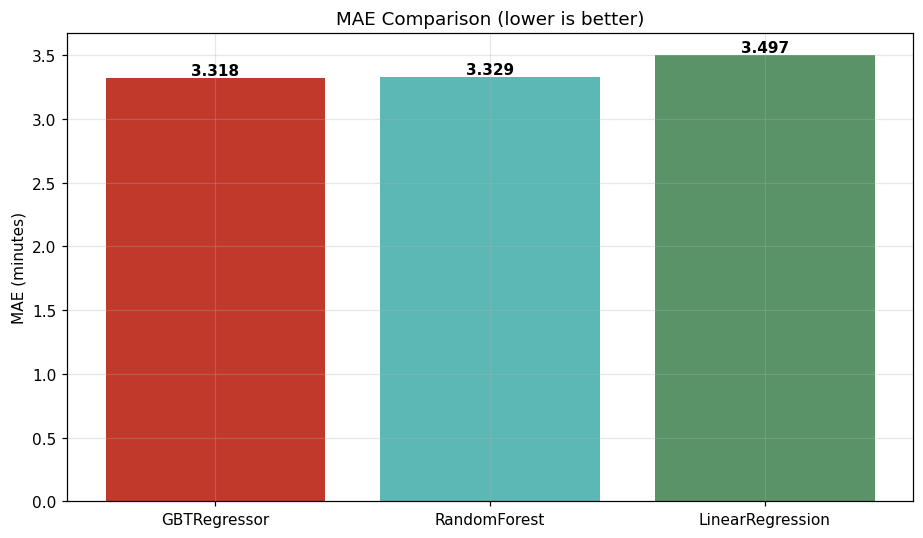

In [52]:
plt.figure(figsize=(8.5,5))
bars = plt.bar(comparison_df["model"], comparison_df["mae"], color=[COL["red"],COL["teal"],COL["green"]])
for b,v in zip(bars, comparison_df["mae"]):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
plt.ylabel("MAE (minutes)"); plt.title("MAE Comparison (lower is better)")
savefig("fig_mae_comparison")

RMSE comparison

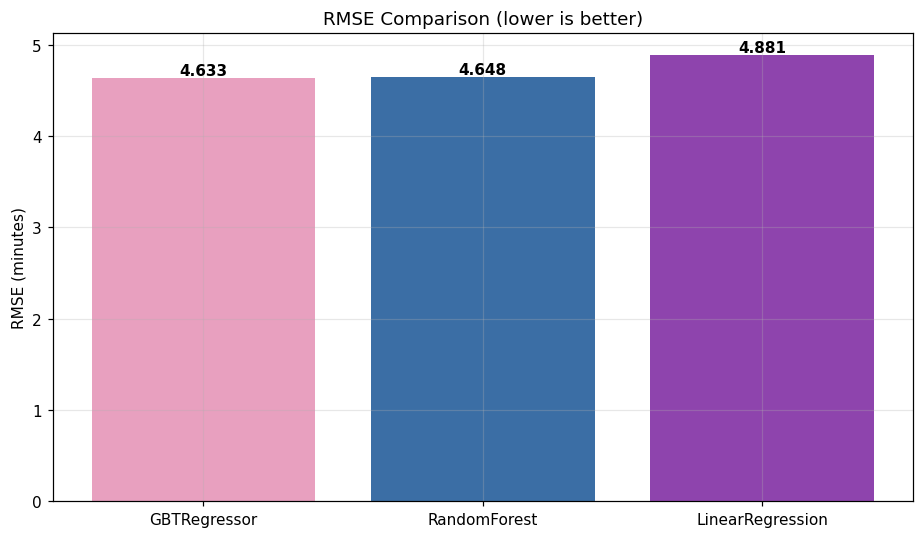

In [53]:
plt.figure(figsize=(8.5,5))
bars = plt.bar(comparison_df["model"], comparison_df["rmse"], color=[COL["pink"],COL["blue"],COL["purple"]])
for b,v in zip(bars, comparison_df["rmse"]):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
plt.ylabel("RMSE (minutes)"); plt.title("RMSE Comparison (lower is better)")
savefig("fig_rmse_comparison")

### training time comparison

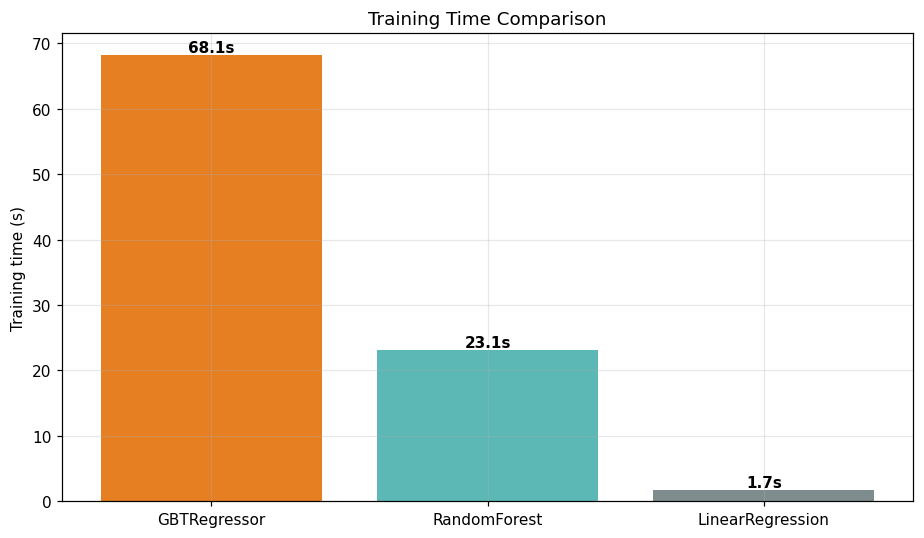

In [54]:
plt.figure(figsize=(8.5,5))
bars = plt.bar(comparison_df["model"], comparison_df["train_time_sec"], color=[COL["orange"],COL["teal"],COL["grey"]])
for b,v in zip(bars, comparison_df["train_time_sec"]):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.1f}s", ha="center", va="bottom", fontweight="bold")
plt.ylabel("Training time (s)"); plt.title("Training Time Comparison")
savefig("fig_train_time")

Model Efficiency (R² per second of training)

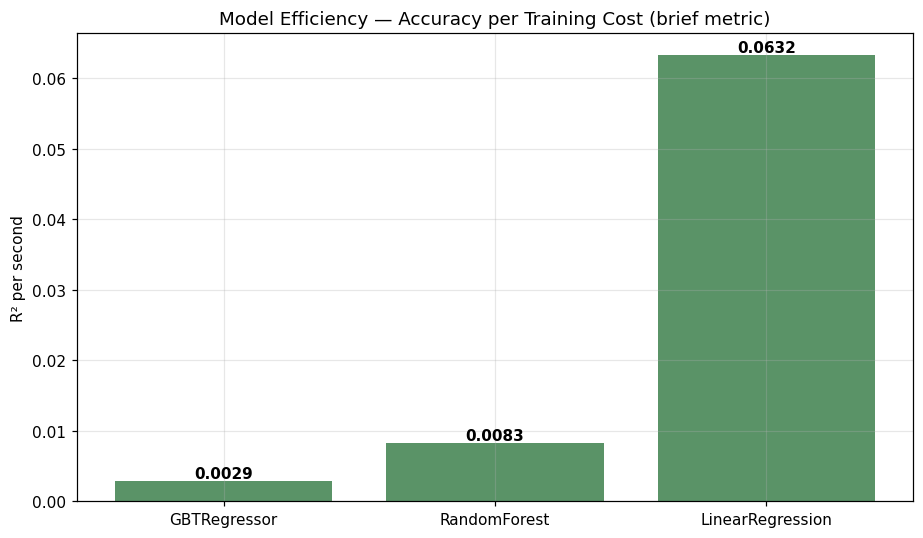

In [55]:
plt.figure(figsize=(8.5,5))
bars = plt.bar(comparison_df["model"], comparison_df["r2_per_second"], color=COL["green"])
for b,v in zip(bars, comparison_df["r2_per_second"]):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.4f}", ha="center", va="bottom", fontweight="bold")
plt.ylabel("R² per second"); plt.title("Model Efficiency — Accuracy per Training Cost (brief metric)")
savefig("fig_model_efficiency")

In [56]:
best_preds = best_model.transform(test_df)
diag = best_preds.select("delay_minutes","prediction").sample(fraction=0.03, seed=42).toPandas()
diag["residual"] = diag["delay_minutes"] - diag["prediction"]
print("Diagnostic sample rows:", len(diag))

Diagnostic sample rows: 4483


actual vs predicted

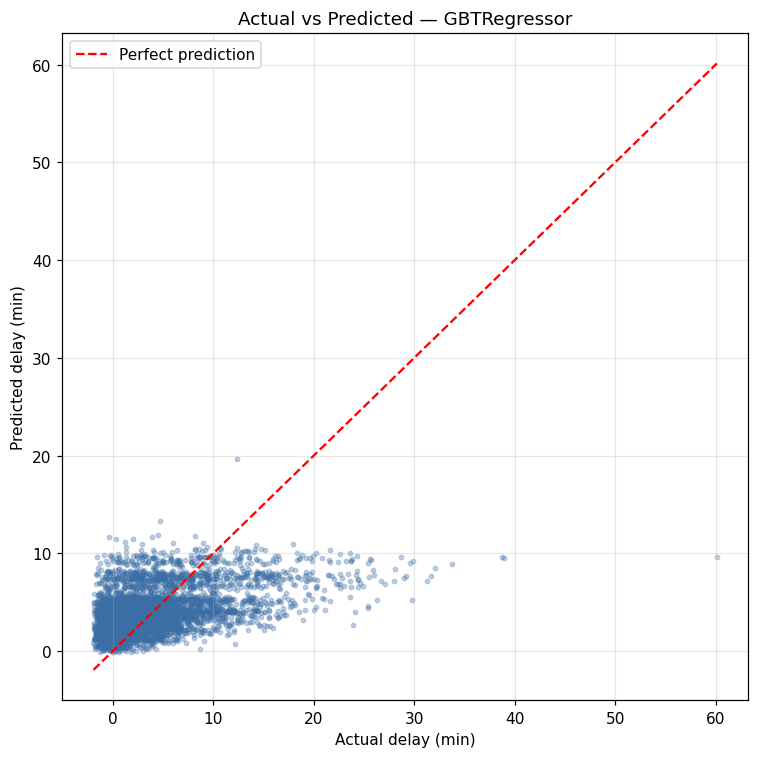

In [57]:
plt.figure(figsize=(7,7))
plt.scatter(diag["delay_minutes"], diag["prediction"], s=8, alpha=0.3, color=COL["blue"])
lims = [diag["delay_minutes"].min(), diag["delay_minutes"].max()]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual delay (min)"); plt.ylabel("Predicted delay (min)")
plt.title(f"Actual vs Predicted — {best_model_name}"); plt.legend()
savefig("fig_actual_vs_pred")

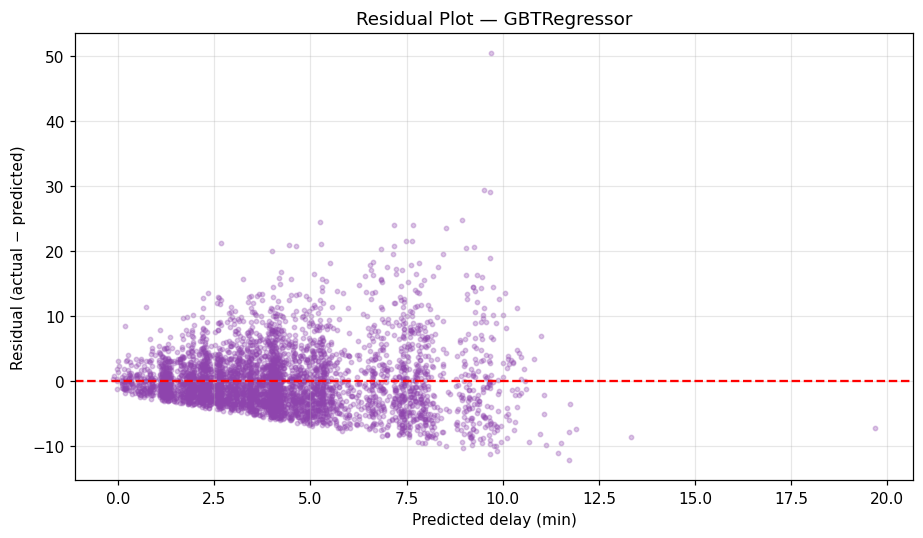

In [58]:
plt.figure(figsize=(8.5,5))
plt.scatter(diag["prediction"], diag["residual"], s=8, alpha=0.3, color=COL["purple"])
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted delay (min)"); plt.ylabel("Residual (actual − predicted)")
plt.title(f"Residual Plot — {best_model_name}")
savefig("fig_residuals")

### Step 56 — Chart — error distribution histogram

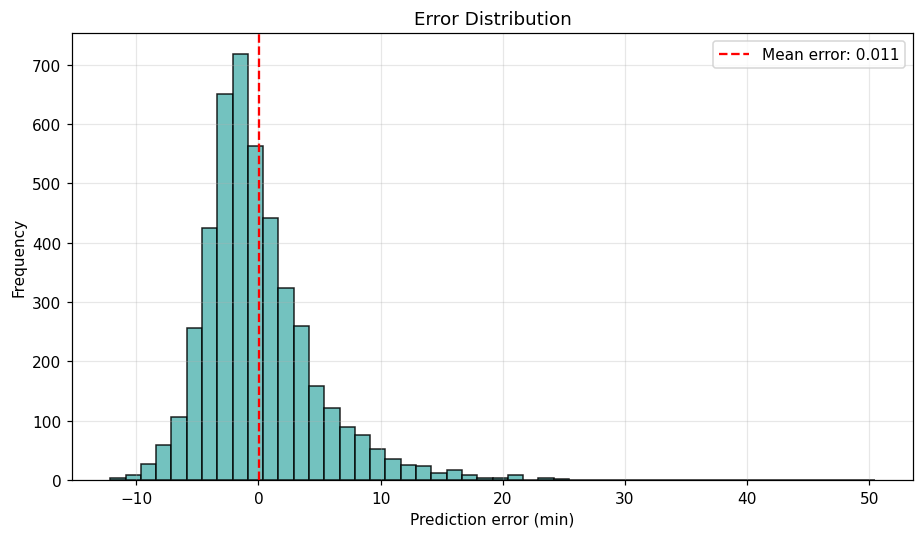

In [59]:
plt.figure(figsize=(8.5,5))
plt.hist(diag["residual"], bins=50, color=COL["teal"], edgecolor="black", alpha=0.85)
plt.axvline(diag["residual"].mean(), color="red", linestyle="--",
            label=f"Mean error: {diag['residual'].mean():.3f}")
plt.legend(); plt.xlabel("Prediction error (min)"); plt.ylabel("Frequency")
plt.title("Error Distribution")
savefig("fig_error_distribution")

error box plot per model

/var/folders/kr/klrznzqx00v33gyy4l2wghcc0000gn/T/ipykernel_32196/2003324808.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(err_data, labels=err_labels, patch_artist=True, showfliers=False)


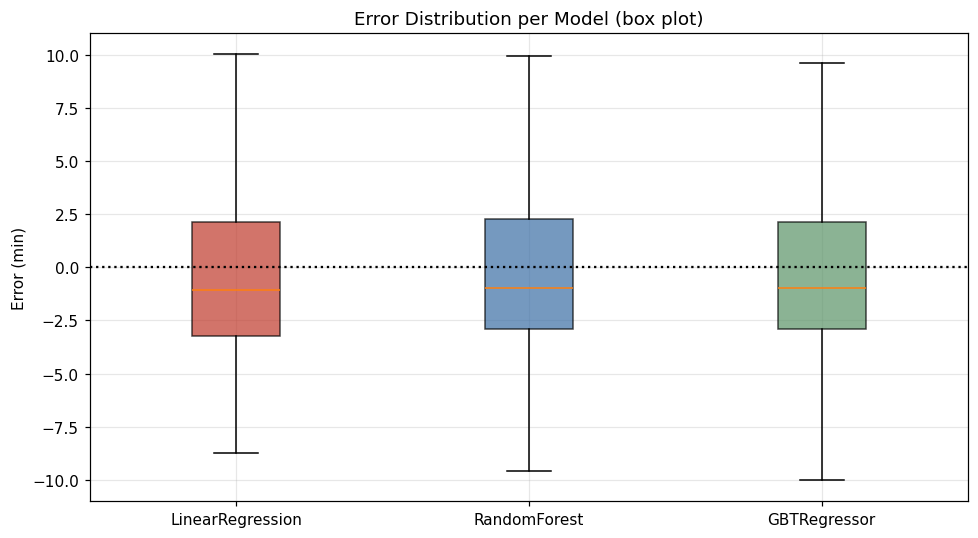

In [60]:
err_data, err_labels = [], []
for name, fm in fitted_models.items():
    pp = fm.transform(test_df).select("delay_minutes","prediction").sample(fraction=0.01, seed=42).toPandas()
    err_data.append((pp["delay_minutes"] - pp["prediction"]).values)
    err_labels.append(name)
plt.figure(figsize=(9,5))
bp = plt.boxplot(err_data, labels=err_labels, patch_artist=True, showfliers=False)
for patch,c in zip(bp['boxes'], [COL["red"],COL["blue"],COL["green"]]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
plt.axhline(0, color="black", linestyle=":")
plt.ylabel("Error (min)"); plt.title("Error Distribution per Model (box plot)")
savefig("fig_error_boxplot")

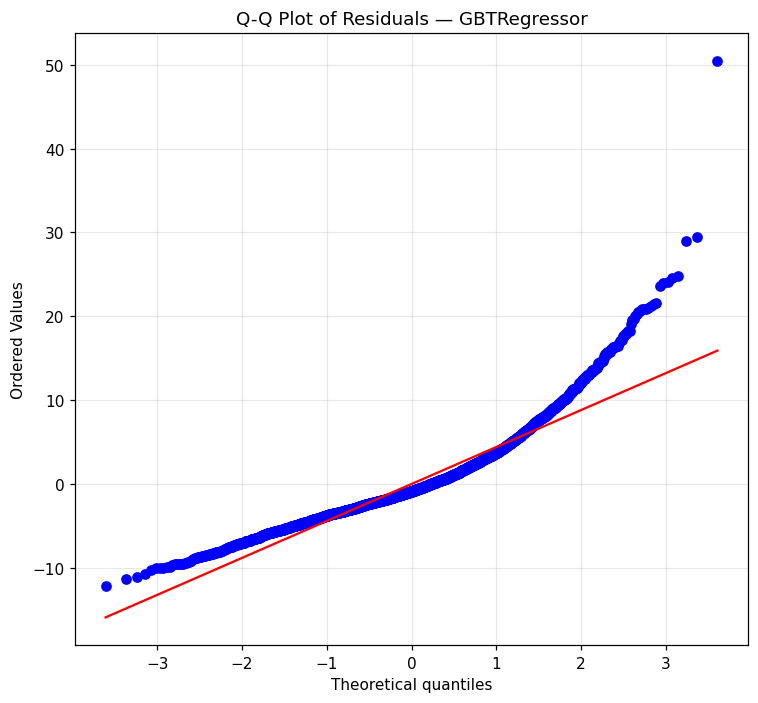

In [61]:
try:
    from scipy import stats as sstats
    plt.figure(figsize=(7,6.5))
    sstats.probplot(diag["residual"], dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of Residuals — {best_model_name}")
    savefig("fig_qq_plot")
except ImportError:
    # manual Q-Q if scipy unavailable
    r = np.sort(diag["residual"].values)
    n = len(r)
    theo = np.percentile(np.random.normal(r.mean(), r.std(), 100000), np.linspace(0.5, 99.5, n))
    plt.figure(figsize=(7,6.5))
    plt.scatter(theo, r, s=6, alpha=0.4, color=COL["blue"])
    lims=[min(theo.min(),r.min()), max(theo.max(),r.max())]
    plt.plot(lims, lims, "r--")
    plt.xlabel("Theoretical quantiles"); plt.ylabel("Sample quantiles")
    plt.title("Q-Q Plot of Residuals (manual)")
    savefig("fig_qq_plot")

feature importance (best tree model)

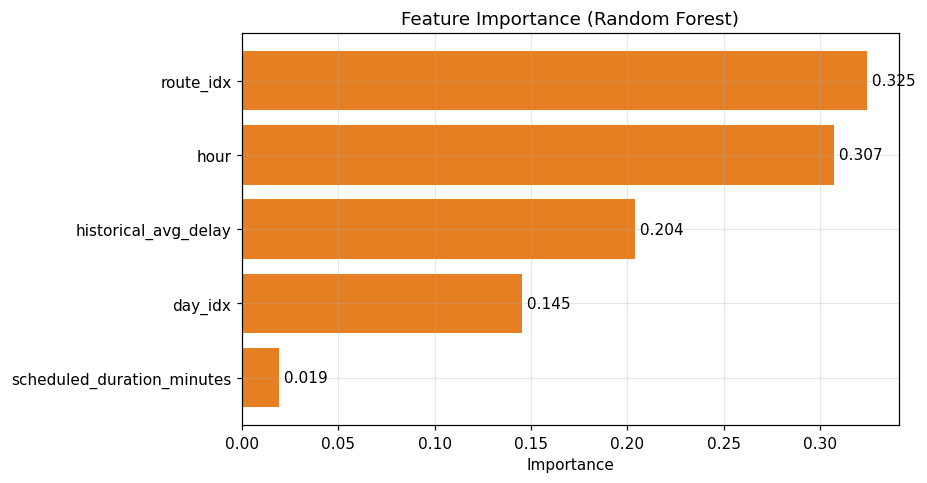

In [62]:
imp_model = fitted_models.get("RandomForest") or fitted_models.get("GBTRegressor")
importances = list(imp_model.featureImportances.toArray())
imp_pd = pd.DataFrame({"feature": FEATURES, "importance": importances}).sort_values("importance")
imp_pd.to_csv("app_data/feature_importance.csv", index=False)
plt.figure(figsize=(8.5,4.5))
plt.barh(imp_pd["feature"], imp_pd["importance"], color=COL["orange"])
for i,v in enumerate(imp_pd["importance"]):
    plt.text(v, i, f" {v:.3f}", va="center")
plt.xlabel("Importance"); plt.title("Feature Importance (Random Forest)")
savefig("fig_feature_importance")

hyperparameter tuning with 3-fold CV

In [63]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
rf = RandomForestRegressor(featuresCol="features", labelCol="delay_minutes", maxBins=320, seed=42)
grid = (ParamGridBuilder().addGrid(rf.numTrees, [20, 50]).addGrid(rf.maxDepth, [5, 8]).build())
cv = CrossValidator(estimator=rf, estimatorParamMaps=grid, evaluator=ev_rmse, numFolds=3, seed=42)
t0 = time.time(); cv_model = cv.fit(train_df); cv_time = time.time()-t0
cv_rmse = ev_rmse.evaluate(cv_model.transform(test_df))
print(f"Best CV RMSE: {cv_rmse:.3f} | best numTrees: {cv_model.bestModel.getNumTrees} | "
      f"best maxDepth: {cv_model.bestModel.getOrDefault('maxDepth')} | CV time: {cv_time:.1f}s")

26/07/18 19:11:28 WARN DAGScheduler: Broadcasting large task binary with size 1305.0 KiB
26/07/18 19:11:46 WARN DAGScheduler: Broadcasting large task binary with size 1085.6 KiB
26/07/18 19:11:49 WARN DAGScheduler: Broadcasting large task binary with size 1760.8 KiB
26/07/18 19:11:52 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/07/18 19:12:07 WARN DAGScheduler: Broadcasting large task binary with size 1293.0 KiB
26/07/18 19:12:27 WARN DAGScheduler: Broadcasting large task binary with size 1080.2 KiB
26/07/18 19:12:30 WARN DAGScheduler: Broadcasting large task binary with size 1763.7 KiB
26/07/18 19:12:33 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/07/18 19:12:50 WARN DAGScheduler: Broadcasting large task binary with size 1287.2 KiB
26/07/18 19:13:09 WARN DAGScheduler: Broadcasting large task binary with size 1073.6 KiB
26/07/18 19:13:12 WARN DAGScheduler: Broadcasting large task binary with size 1747.5 KiB
26/07/18 19:13:15 WARN DAGS

Best CV RMSE: 4.648 | best numTrees: 50 | best maxDepth: 8 | CV time: 149.9s


 CrossValidator grid results

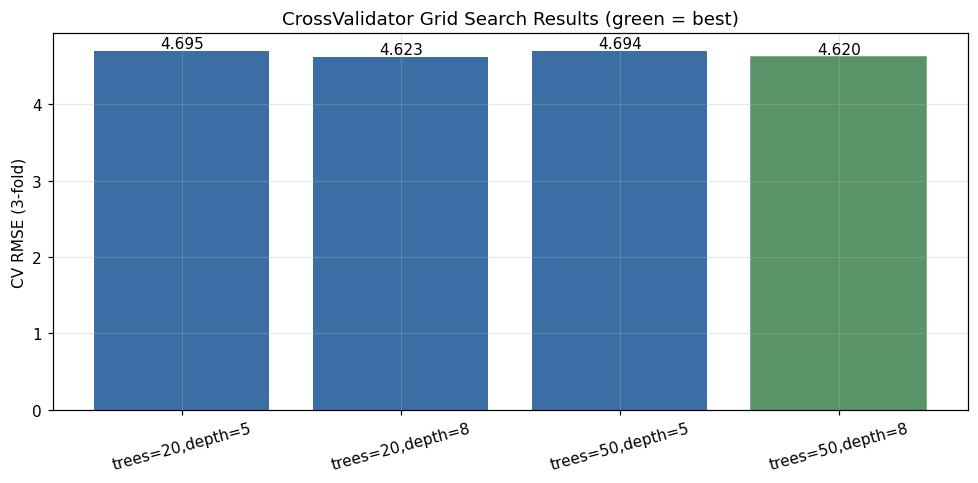

In [64]:
cv_metrics = cv_model.avgMetrics
labels = [f"trees={p[rf.numTrees]},depth={p[rf.maxDepth]}" for p in grid]
plt.figure(figsize=(9,4.5))
bars = plt.bar(labels, cv_metrics, color=COL["blue"])
best_i = int(np.argmin(cv_metrics))
bars[best_i].set_color(COL["green"])
for b,v in zip(bars, cv_metrics):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom")
plt.ylabel("CV RMSE (3-fold)"); plt.title("CrossValidator Grid Search Results (green = best)")
plt.xticks(rotation=15)
savefig("fig_cv_grid")

ompliance classification layer / label trips compliant / non-compliant (±2 min)

In [65]:
# Service Reliability tolerance from the brief: within ±2 minutes = compliant (label 0)
train_cls = train_df.withColumn("label", F.when(F.abs(F.col("delay_minutes")) <= 2.0, 0.0).otherwise(1.0))
test_cls  = test_df.withColumn("label",  F.when(F.abs(F.col("delay_minutes")) <= 2.0, 0.0).otherwise(1.0))
balance = train_cls.groupBy("label").count().toPandas()
print(balance)

   label   count
0    1.0  425948
1    0.0  319482


 Chart — class balance (compliant vs non-compliant)

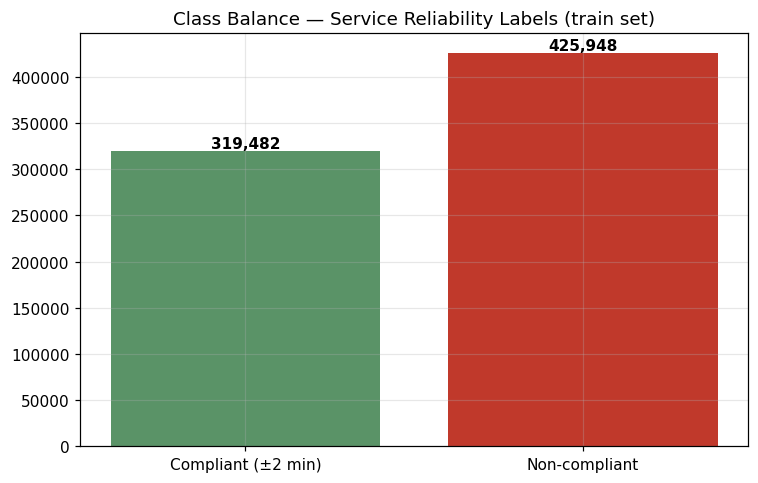

In [66]:
lbls = ["Compliant (±2 min)","Non-compliant"]
vals = [int(balance[balance.label==0.0]['count'].iloc[0]), int(balance[balance.label==1.0]['count'].iloc[0])]
plt.figure(figsize=(7,4.5))
bars = plt.bar(lbls, vals, color=[COL["green"], COL["red"]])
for b,v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
plt.title("Class Balance — Service Reliability Labels (train set)")
savefig("fig_class_balance")

Train the compliance classifier (Logistic Regression)

In [67]:
from pyspark.ml.classification import LogisticRegression as LogReg
clf = LogReg(featuresCol="features", labelCol="label", maxIter=30)
t0 = time.time(); clf_model = clf.fit(train_cls); clf_time = time.time()-t0
cls_preds = clf_model.transform(test_cls).cache()
print(f"Classifier trained in {clf_time:.1f}s")

Classifier trained in 2.6s


Evaluate classifier — Accuracy, Precision, Recall, F1, AUC

In [68]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
acc  = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy").evaluate(cls_preds)
prec = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision").evaluate(cls_preds)
rec  = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall").evaluate(cls_preds)
f1   = MulticlassClassificationEvaluator(labelCol="label", metricName="f1").evaluate(cls_preds)
auc  = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC").evaluate(cls_preds)
cls_metrics = pd.DataFrame([{"accuracy":acc,"precision":prec,"recall":rec,"f1":f1,"auc":auc}]).round(3)
cls_metrics.to_csv("app_data/classification_metrics.csv", index=False)
print(cls_metrics.to_string(index=False))

 accuracy  precision  recall    f1  auc
    0.637      0.631   0.637 0.624 0.66


Accuracy / Precision / Recall / F1 bar

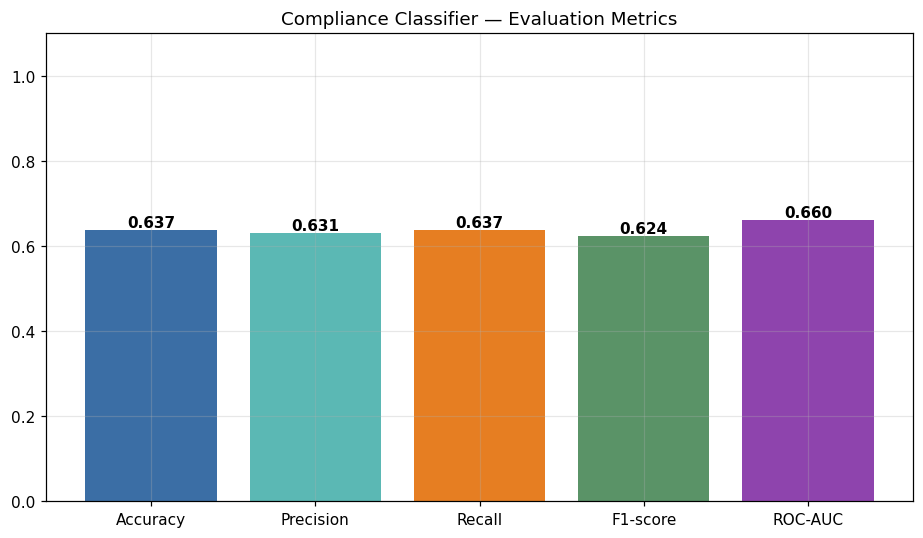

In [69]:
m = cls_metrics.iloc[0]
plt.figure(figsize=(8.5,5))
names = ["Accuracy","Precision","Recall","F1-score","ROC-AUC"]
vals = [m["accuracy"], m["precision"], m["recall"], m["f1"], m["auc"]]
bars = plt.bar(names, vals, color=[COL["blue"],COL["teal"],COL["orange"],COL["green"],COL["purple"]])
for b,v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
plt.ylim(0, 1.1); plt.title("Compliance Classifier — Evaluation Metrics")
savefig("fig_cls_metrics")

 confusion matrix heatmap

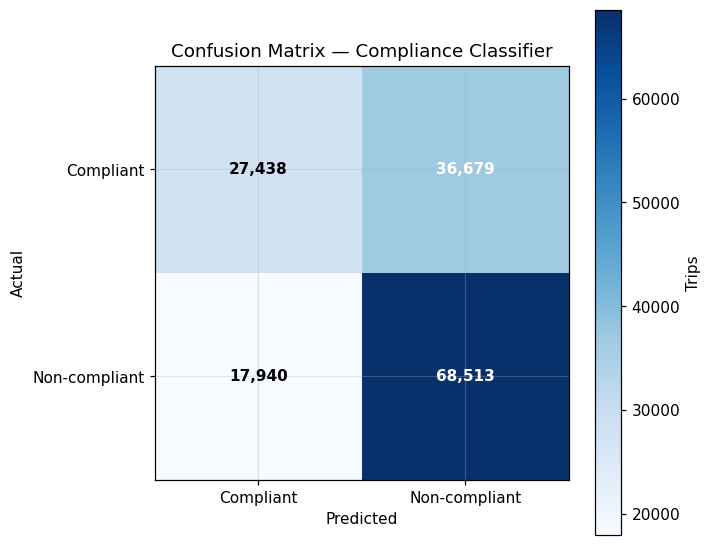

In [70]:
cmx = (cls_preds.groupBy("label","prediction").count().toPandas()
       .pivot(index="label", columns="prediction", values="count").fillna(0).astype(int))
cm_arr = cmx.reindex(index=[0.0,1.0], columns=[0.0,1.0], fill_value=0).values
plt.figure(figsize=(6.5,5.5))
plt.imshow(cm_arr, cmap="Blues")
plt.colorbar(label="Trips")
ticks = ["Compliant","Non-compliant"]
plt.xticks([0,1], ticks); plt.yticks([0,1], ticks)
plt.xlabel("Predicted"); plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm_arr[i,j]:,}", ha="center", va="center",
                 color="white" if cm_arr[i,j] > cm_arr.max()/2 else "black", fontweight="bold")
plt.title("Confusion Matrix — Compliance Classifier")
savefig("fig_confusion_matrix")
pd.DataFrame(cm_arr, index=ticks, columns=ticks).to_csv("app_data/confusion_matrix.csv")

ROC curve

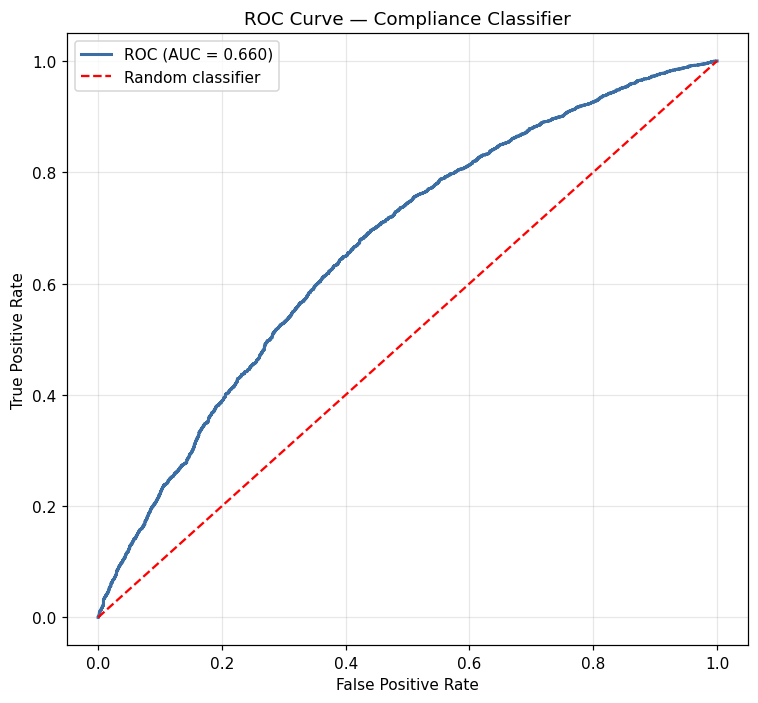

In [71]:
from pyspark.ml.functions import vector_to_array
roc_sample = (cls_preds
    .withColumn("p1", vector_to_array("probability")[1])
    .select("label","p1").sample(fraction=0.05, seed=42).toPandas())
try:
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(roc_sample["label"], roc_sample["p1"])
except ImportError:
    ths = np.linspace(0, 1, 101)
    P = (roc_sample["label"]==1).sum(); N = (roc_sample["label"]==0).sum()
    tpr = [( (roc_sample["p1"]>=t) & (roc_sample["label"]==1) ).sum()/P for t in ths]
    fpr = [( (roc_sample["p1"]>=t) & (roc_sample["label"]==0) ).sum()/N for t in ths]
pd.DataFrame({"fpr":fpr,"tpr":tpr}).to_csv("app_data/roc_points.csv", index=False)
plt.figure(figsize=(7,6.5))
plt.plot(fpr, tpr, color=COL["blue"], linewidth=2, label=f"ROC (AUC = {cls_metrics.iloc[0]['auc']:.3f})")
plt.plot([0,1],[0,1], "r--", label="Random classifier")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Compliance Classifier"); plt.legend()
savefig("fig_roc_curve")

\Algorithm complexity and measured scalability (training time vs data size)

In [72]:
fractions = [0.1, 0.25, 0.5, 1.0]
scal_times, scal_sizes = [], []
for fr in fractions:
    sub = train_df.sample(fraction=fr, seed=42)
    n = sub.count()
    rf_s = RandomForestRegressor(featuresCol="features", labelCol="delay_minutes",
                                 numTrees=20, maxDepth=6, maxBins=320, seed=42)
    t0 = time.time(); rf_s.fit(sub); el = time.time()-t0
    scal_times.append(el); scal_sizes.append(n)
    print(f"fraction={fr:.2f} rows={n:,} train_time={el:.1f}s")

fraction=0.10 rows=74,529 train_time=1.7s
fraction=0.25 rows=186,864 train_time=2.4s


fraction=0.50 rows=373,691 train_time=3.6s


[Stage 4285:============================>                           (4 + 4) / 8]

fraction=1.00 rows=745,430 train_time=6.2s


 scalability: training time vs dataset size (measured)

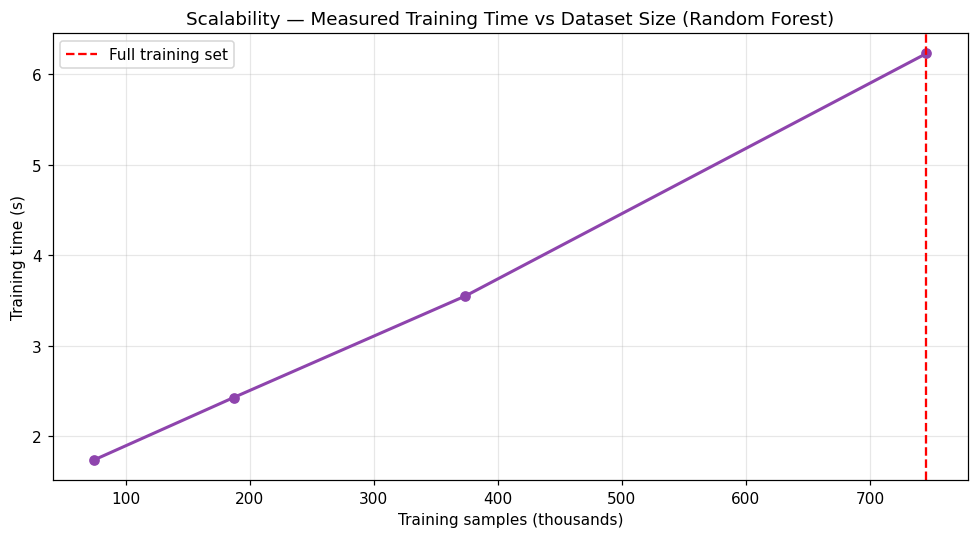

In [73]:
plt.figure(figsize=(9,5))
plt.plot([s/1000 for s in scal_sizes], scal_times, marker="o", color=COL["purple"], linewidth=2)
plt.axvline(scal_sizes[-1]/1000, color="red", linestyle="--", label="Full training set")
plt.xlabel("Training samples (thousands)"); plt.ylabel("Training time (s)")
plt.title("Scalability — Measured Training Time vs Dataset Size (Random Forest)")
plt.legend()
savefig("fig_scalability")

 theoretical training-complexity components (Big-O terms)

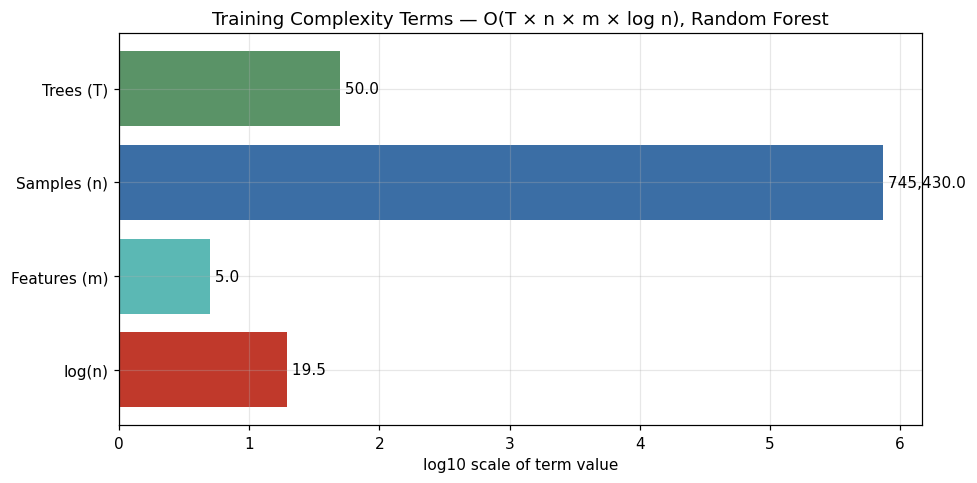

In [74]:
n_feat = len(FEATURES); n_trees = 50; n_samples = n_train
plt.figure(figsize=(9,4.5))
comps = ["Trees (T)", "Samples (n)", "Features (m)", "log(n)"]
vals = [n_trees, n_samples, n_feat, np.log2(max(n_samples,2))]
bars = plt.barh(comps[::-1], [np.log10(max(v,1.0001)) for v in vals][::-1],
                color=[COL["red"],COL["teal"],COL["blue"],COL["green"]])
for b, v in zip(bars, [vals[3], vals[2], vals[1], vals[0]]):
    plt.text(b.get_width(), b.get_y()+b.get_height()/2, f" {v:,.1f}", va="center")
plt.xlabel("log10 scale of term value")
plt.title("Training Complexity Terms — O(T × n × m × log n), Random Forest")
savefig("fig_complexity_terms")

relative training time by algorithm (measured, normalised)

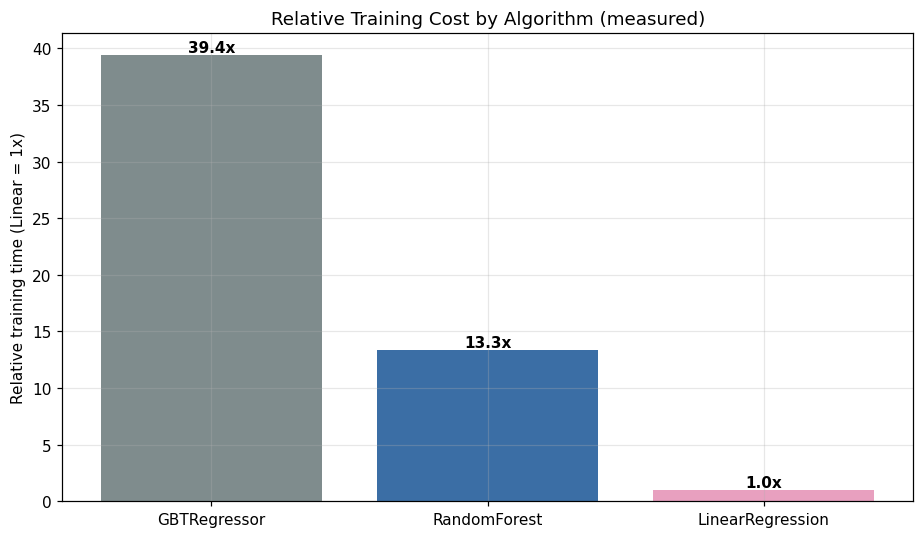

In [75]:
base = comparison_df[comparison_df.model=="LinearRegression"]["train_time_sec"].iloc[0]
rel = comparison_df.copy(); rel["relative"] = rel["train_time_sec"]/max(base, 0.01)
plt.figure(figsize=(8.5,5))
bars = plt.bar(rel["model"], rel["relative"], color=[COL["grey"],COL["blue"],COL["pink"]])
for b,v in zip(bars, rel["relative"]):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.1f}x", ha="center", va="bottom", fontweight="bold")
plt.ylabel("Relative training time (Linear = 1x)")
plt.title("Relative Training Cost by Algorithm (measured)")
savefig("fig_relative_cost")

measured inference latency per model

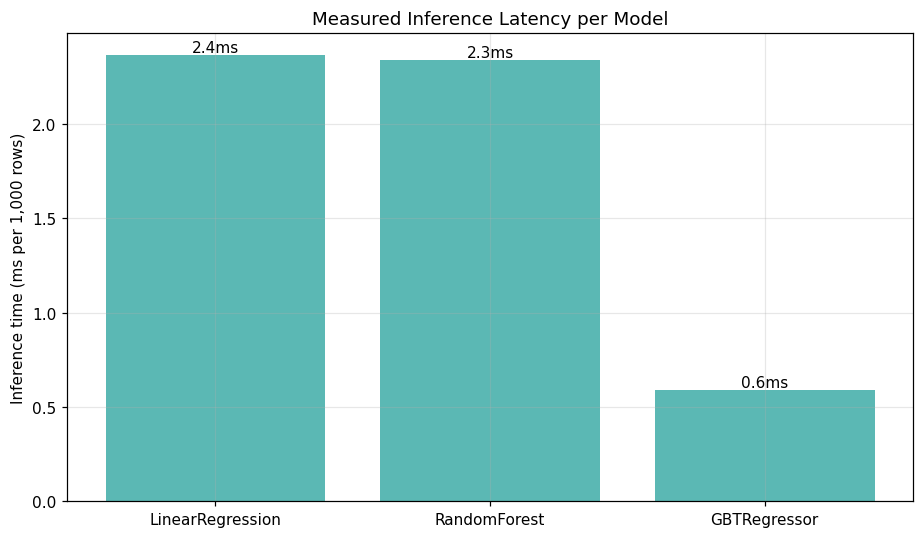

In [76]:
inf_times = []
for name, fm in fitted_models.items():
    t0 = time.time(); fm.transform(test_df).count(); el = time.time()-t0
    per_1k = 1000*el/max(n_test,1)*1000  # ms per 1k rows
    inf_times.append({"model":name, "ms_per_1k_rows": per_1k})
inf_pd = pd.DataFrame(inf_times)
plt.figure(figsize=(8.5,5))
bars = plt.bar(inf_pd["model"], inf_pd["ms_per_1k_rows"], color=COL["teal"])
for b,v in zip(bars, inf_pd["ms_per_1k_rows"]):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.1f}ms", ha="center", va="bottom")
plt.ylabel("Inference time (ms per 1,000 rows)")
plt.title("Measured Inference Latency per Model")
savefig("fig_inference_latency")

 Per-route predicted delay & Service Reliability rate

In [77]:
all_preds = best_model.transform(trips_ml_ready)
route_stats = (all_preds.groupBy("route_description").agg(
    F.mean("prediction").alias("predicted_avg_delay"),
    F.mean(F.when(F.abs(F.col("prediction")) <= 2, 1).otherwise(0)).alias("service_reliability_rate"),
    F.count("*").alias("trip_count"),
).filter(F.col("trip_count") > 100))
print("Routes scored:", route_stats.count())

Routes scored: 249


 Broadcast join — attach route metadata (optimisation evidence)

In [78]:
from pyspark.sql.functions import broadcast
route_meta = trips_clean.select("route_description","line_name","direction").distinct()
route_stats_enriched = route_stats.join(broadcast(route_meta), "route_description", "left")
route_stats_enriched.show(5, truncate=False)

[Stage 4361:>                                                       (0 + 1) / 1]

+---------------------------------------------------------+-------------------+------------------------+----------+---------+---------+
|route_description                                        |predicted_avg_delay|service_reliability_rate|trip_count|line_name|direction|
+---------------------------------------------------------+-------------------+------------------------+----------+---------+---------+
|Aintree Hosp - Kirby Ind Est                             |2.623937434230464  |0.11496746203904555     |922       |17       |outbound |
|Birkenhead Bus Station - Eastham Ferry                   |4.747354460624989  |0.0                     |365       |38       |inbound  |
|Bootle Bus Station, Stand 1 - Bootle Bus Station, Stand 1|3.335701294194332  |0.1363834422657952      |2295      |235      |outbound |
|Brookway Lane - Mill Lane                                |0.6341693049322292 |1.0                     |261       |720      |inbound  |
|Chester - Blacon Parade                        

 irregularity per route (window function)

In [79]:
from pyspark.sql.functions import unix_timestamp
hb = (trips_clean.select("route_description","scheduled_departure_time").distinct()
      .withColumn("dep_seconds", unix_timestamp(F.concat(F.lit("2000-01-01 "), F.col("scheduled_departure_time")))))
wh = Window.partitionBy("route_description").orderBy("dep_seconds")
gaps = hb.withColumn("gap", F.col("dep_seconds") - F.lag("dep_seconds").over(wh))
headway_stats = (gaps.groupBy("route_description").agg(
    F.stddev("gap").alias("h_std"), F.mean("gap").alias("h_mean"))
    .withColumn("headway_irregularity", F.col("h_std")/F.col("h_mean")))
print("Headway computed for", headway_stats.count(), "routes")

Headway computed for 294 routes


 Combine into the composite Route Risk Score

In [80]:
route_risk = (route_stats
    .join(headway_stats.select("route_description","headway_irregularity"), "route_description", "left")
    .fillna({"headway_irregularity": 0.5}))
s = route_risk.agg(
    F.min("predicted_avg_delay").alias("min_d"), F.max("predicted_avg_delay").alias("max_d"),
    F.min("headway_irregularity").alias("min_h"), F.max("headway_irregularity").alias("max_h")).first()
route_risk = (route_risk
    .withColumn("norm_delay", (F.col("predicted_avg_delay")-s["min_d"])/(s["max_d"]-s["min_d"]+1e-6))
    .withColumn("norm_headway", (F.col("headway_irregularity")-s["min_h"])/(s["max_h"]-s["min_h"]+1e-6))
    .withColumn("route_risk_score",
        0.5*F.col("norm_delay") + 0.25*F.col("norm_headway") + 0.25*(1-F.col("service_reliability_rate"))))
risk_pd = route_risk.toPandas().sort_values("route_risk_score", ascending=False)
risk_pd.to_csv("app_data/route_risk.csv", index=False)
print(risk_pd.head(10)[["route_description","route_risk_score"]].to_string(index=False))

[Stage 4436:==============================================>         (5 + 1) / 6]

                                               route_description  route_risk_score
                                                 Kirkby - Kirkby          0.807496
                          Seaforth Station - Maghull High School          0.781020
                                      Alton Road - College Drive          0.776943
                                Freckleton Road - Rectory Avenue          0.776930
                                 Spurriers Lane - Spring Gardens          0.776613
                               McCulloch Street - Cowley College          0.774130
Newton Hospital - Byrchall and St Edmund Arrowsmith High Schools          0.761044
             Jubits Lane - Rainford High School Internal Grounds          0.757843
      Chester Bus Interchange, Stand C - Christleton High School          0.750486
      Runcorn Halton Lea Shopping City - Chester Bus Interchange          0.748691


route Risk Score top 10 (priority list)

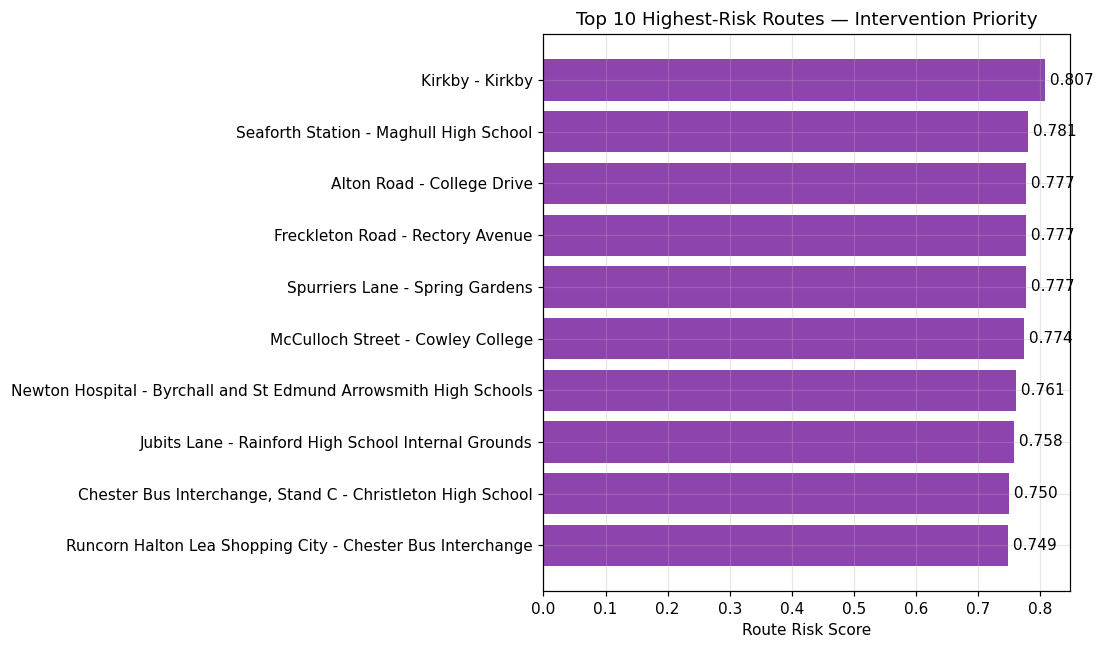

In [81]:
top10 = risk_pd.head(10)
plt.figure(figsize=(10,6))
plt.barh(top10["route_description"][::-1], top10["route_risk_score"][::-1], color=COL["purple"])
for i,v in enumerate(top10["route_risk_score"][::-1]):
    plt.text(v, i, f" {v:.3f}", va="center")
plt.xlabel("Route Risk Score"); plt.title("Top 10 Highest-Risk Routes — Intervention Priority")
savefig("fig_risk_top10")

risk score component breakdown (stacked, top 10)

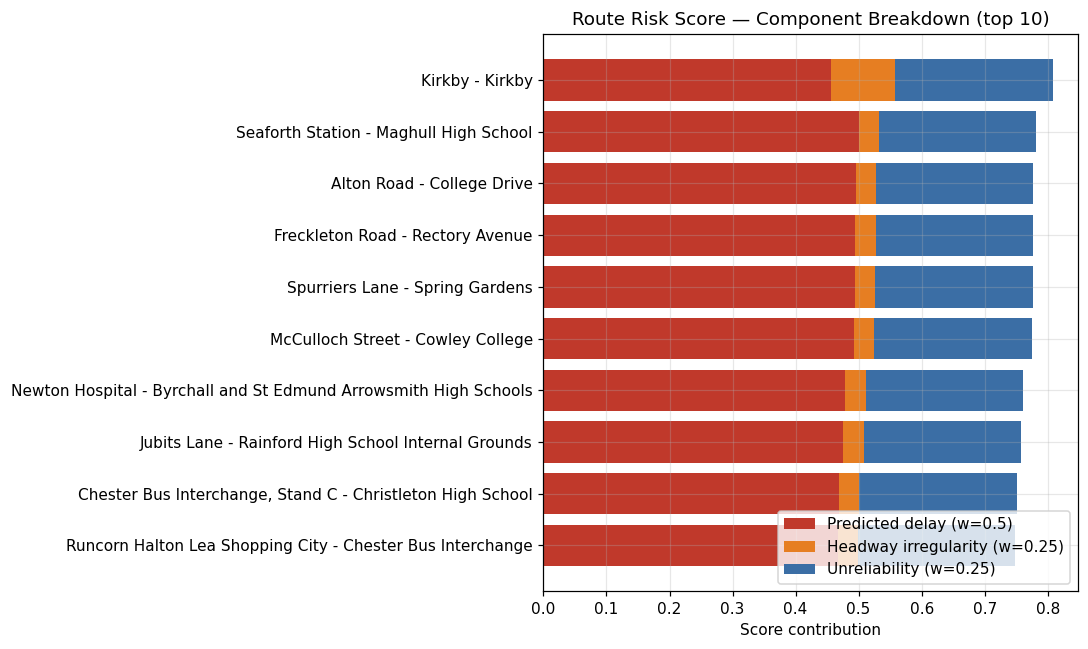

In [82]:
comp = top10.copy()
comp["delay_part"] = 0.5*comp["norm_delay"]
comp["headway_part"] = 0.25*comp["norm_headway"]
comp["reliability_part"] = 0.25*(1-comp["service_reliability_rate"])
plt.figure(figsize=(10,6))
b1 = plt.barh(comp["route_description"][::-1], comp["delay_part"][::-1], color=COL["red"], label="Predicted delay (w=0.5)")
b2 = plt.barh(comp["route_description"][::-1], comp["headway_part"][::-1],
              left=comp["delay_part"][::-1], color=COL["orange"], label="Headway irregularity (w=0.25)")
plt.barh(comp["route_description"][::-1], comp["reliability_part"][::-1],
         left=(comp["delay_part"]+comp["headway_part"])[::-1], color=COL["blue"], label="Unreliability (w=0.25)")
plt.legend(loc="lower right"); plt.xlabel("Score contribution")
plt.title("Route Risk Score — Component Breakdown (top 10)")
savefig("fig_risk_components")

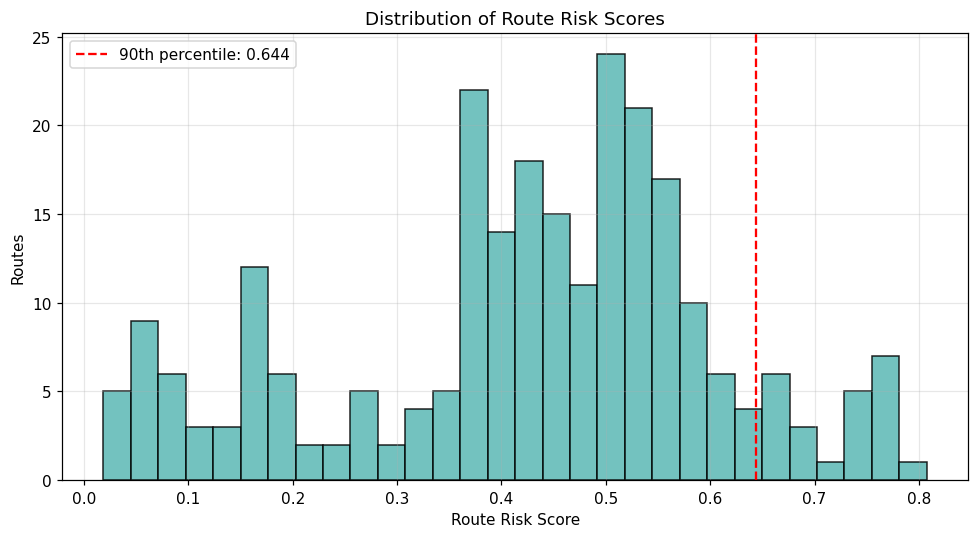

In [83]:
plt.figure(figsize=(9,5))
plt.hist(risk_pd["route_risk_score"], bins=30, color=COL["teal"], edgecolor="black", alpha=0.85)
thr = risk_pd["route_risk_score"].quantile(0.9)
plt.axvline(thr, color="red", linestyle="--", label=f"90th percentile: {thr:.3f}")
plt.legend(); plt.xlabel("Route Risk Score"); plt.ylabel("Routes")
plt.title("Distribution of Route Risk Scores")
savefig("fig_risk_distribution")

reliability vs predicted delay (coloured by risk)

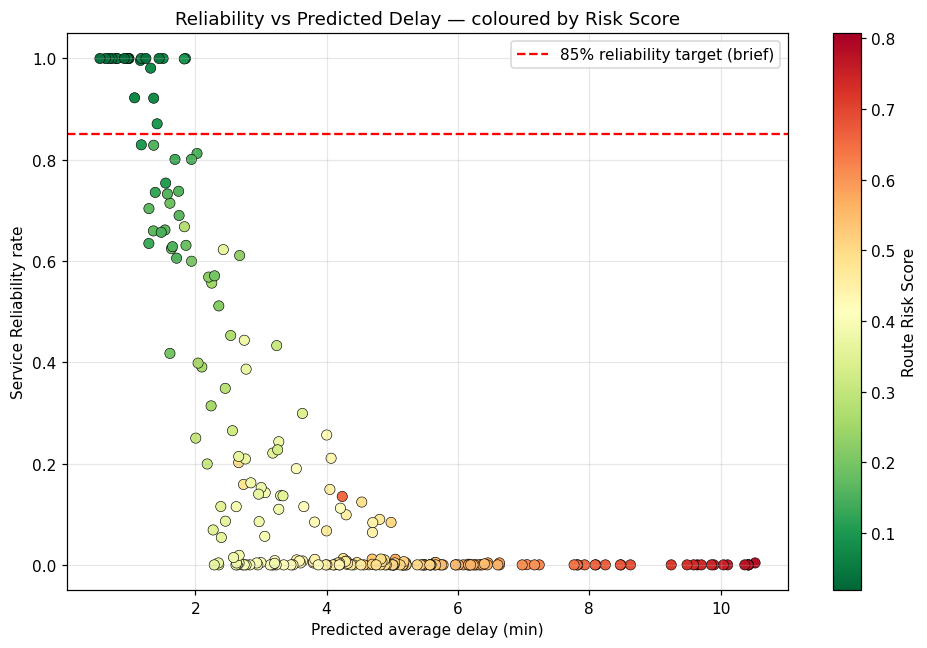

In [84]:
plt.figure(figsize=(9,6))
sc = plt.scatter(risk_pd["predicted_avg_delay"], risk_pd["service_reliability_rate"],
                 c=risk_pd["route_risk_score"], cmap="RdYlGn_r", s=45, edgecolors="black", linewidths=0.4)
plt.colorbar(sc, label="Route Risk Score")
plt.axhline(0.85, color="red", linestyle="--", label="85% reliability target (brief)")
plt.legend()
plt.xlabel("Predicted average delay (min)"); plt.ylabel("Service Reliability rate")
plt.title("Reliability vs Predicted Delay — coloured by Risk Score")
savefig("fig_reliability_vs_delay")

reliability vs delay coloured by risk**

 Service Reliability: best & worst routes vs the 85% target

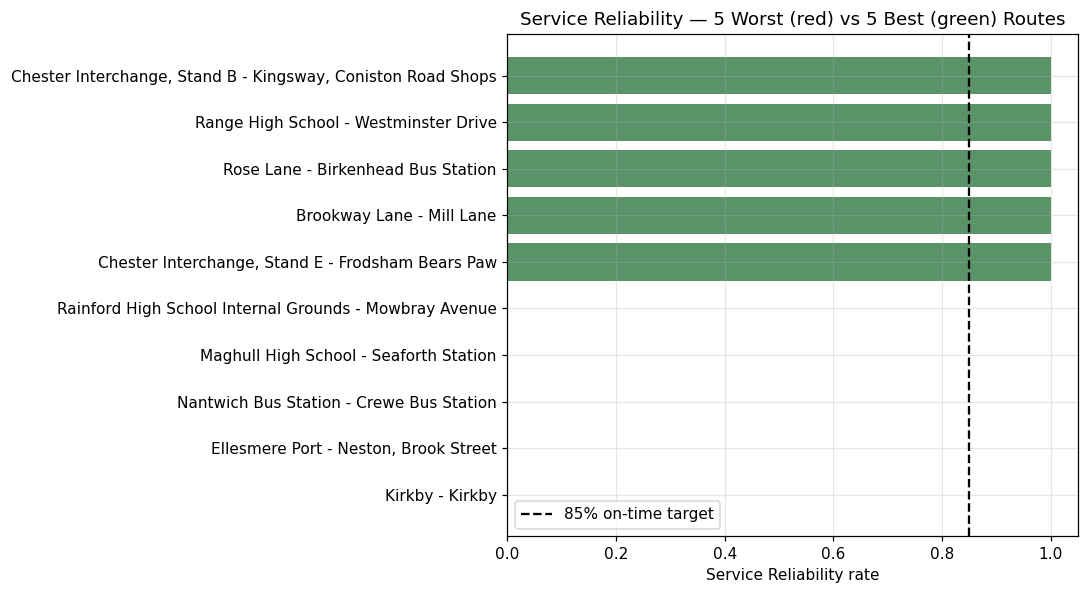

In [85]:
rr = risk_pd.sort_values("service_reliability_rate")
sel = pd.concat([rr.head(5), rr.tail(5)])
plt.figure(figsize=(10,5.5))
colors = [COL["red"]]*5 + [COL["green"]]*5
plt.barh(sel["route_description"], sel["service_reliability_rate"], color=colors)
plt.axvline(0.85, color="black", linestyle="--", label="85% on-time target")
plt.legend(); plt.xlabel("Service Reliability rate")
plt.title("Service Reliability — 5 Worst (red) vs 5 Best (green) Routes")
savefig("fig_reliability_target")

Store results in SQLite with parameterised querie

In [86]:
import sqlite3
conn = sqlite3.connect("bus_delay_project.db")
cur = conn.cursor()
cur.execute('''CREATE TABLE IF NOT EXISTS route_risk_scores (
    route_description TEXT PRIMARY KEY,
    predicted_avg_delay REAL, headway_irregularity REAL,
    service_reliability_rate REAL, route_risk_score REAL)''')
records = list(risk_pd[["route_description","predicted_avg_delay","headway_irregularity",
                        "service_reliability_rate","route_risk_score"]].itertuples(index=False, name=None))
cur.executemany("INSERT OR REPLACE INTO route_risk_scores VALUES (?, ?, ?, ?, ?)", records)  # parameterised
conn.commit()
threshold = 0.5
cur.execute("SELECT route_description, route_risk_score FROM route_risk_scores WHERE route_risk_score > ? ORDER BY route_risk_score DESC LIMIT 5", (threshold,))
for row in cur.fetchall(): print("  ", row)
conn.close()
print("Database written with parameterised INSERT + SELECT.")

   ('Kirkby - Kirkby', 0.8074958315756554)
   ('Seaforth Station - Maghull High School', 0.781019556003216)
   ('Alton Road - College Drive', 0.7769434174659362)
   ('Freckleton Road - Rectory Avenue', 0.7769297147246031)
   ('Spurriers Lane - Spring Gardens', 0.7766132712145001)
Database written with parameterised INSERT + SELECT.


#Export the database schema + SQL dump

In [87]:
import sqlite3
conn = sqlite3.connect("bus_delay_project.db")
with open("bus_delay_project_dump.sql", "w") as f:
    for line in conn.iterdump():
        f.write(line + "\n")
schema = conn.execute("SELECT sql FROM sqlite_master WHERE type='table'").fetchall()
conn.close()
print("SQL dump written: bus_delay_project_dump.sql")
for s in schema: print(s[0])

SQL dump written: bus_delay_project_dump.sql
CREATE TABLE route_risk_scores (
    route_description TEXT PRIMARY KEY,
    predicted_avg_delay REAL, headway_irregularity REAL,
    service_reliability_rate REAL, route_risk_score REAL)


In [88]:
spark.stop()
print("Spark session stopped. All figures saved in ./figures, app data in ./app_data, models in ./models")

Spark session stopped. All figures saved in ./figures, app data in ./app_data, models in ./models
